# Real-Time Driver Drowsiness Detection menggunakan Faster R-CNN
## Dataset: NTHU-DDD Multi-Class (Kaggle)

---

- Benedict Aurelius (2306209095)
- Deandro Najwan Ahmad Syahbanna (2306213174)
- Nelson Laurensius (2306161845)
- Wesley Frederick Oh (2306202763)

## BAGIAN 1: Environment Setup

In [1]:
# ============================================================
# 1.1 Instalasi Library
# ============================================================
import subprocess, sys

def install(pkg):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q'] + pkg.split())

packages = [
    'torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118',
    'opencv-python-headless',
    'albumentations',
    'kaggle',
    'matplotlib seaborn',
    'tqdm',
    'Pillow',
    'pandas',
    'scikit-learn',
    'pycocotools',
    'torchmetrics',
    'ipywidgets',
    'mediapipe'
]

for pkg in packages:
    try:
        install(pkg)
        print(f'✅ {pkg.split()[0]} installed')
    except Exception as e:
        print(f'⚠️  {pkg.split()[0]}: {e}')

✅ torch installed
✅ opencv-python-headless installed
✅ albumentations installed
✅ kaggle installed
✅ matplotlib installed
✅ tqdm installed
✅ Pillow installed
✅ pandas installed
✅ scikit-learn installed
✅ pycocotools installed
✅ torchmetrics installed
✅ ipywidgets installed
✅ mediapipe installed


In [ ]:
# ============================================================
# 1.2 Import Library
# ============================================================
import os, sys, json, time, random, shutil, warnings, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
from pathlib import Path
from PIL import Image
from tqdm.notebook import tqdm
from collections import Counter, defaultdict
from copy import deepcopy
from google.colab import drive

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import torchvision
from torchvision.models.detection import fasterrcnn_resnet50_fpn, FasterRCNN_ResNet50_FPN_Weights
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
import torchvision.transforms.functional as F

# OpenCV
import cv2

# Augmentasi
import albumentations as A
from albumentations.pytorch import ToTensorV2

# Metrics
from sklearn.metrics import classification_report, confusion_matrix
from torchmetrics.detection.mean_ap import MeanAveragePrecision

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 110

# ============================================================
# 1.3 Konfigurasi Device
# ============================================================
drive.mount('/content/drive')
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'🖥️  Device: {DEVICE}')

if torch.cuda.is_available():
    print(f'   GPU : {torch.cuda.get_device_name(0)}')
    print(f'   VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

# ============================================================
# 1.4 Hyperparameter & Path
# ============================================================
CFG = {
    # Path
    'DATA_ROOT'     : './nthu_ddd',
    'ANNO_DIR'      : './annotations',
    'CHECKPOINT_DIR': '/content/drive/MyDrive/checkpoints',
    'LOG_DIR'       : './logs',

    # Dataset
    'IMG_SIZE'      : 640,
    'TRAIN_RATIO'   : 0.75,
    'VAL_RATIO'     : 0.15,
    'TEST_RATIO'    : 0.10,

    # Training
    'BATCH_SIZE'    : 4,
    'NUM_EPOCHS'    : 20,
    'LR'            : 0.005,
    'MOMENTUM'      : 0.9,
    'WEIGHT_DECAY'  : 5e-4,
    'LR_STEP_SIZE'  : 7,
    'LR_GAMMA'      : 0.1,
    'NUM_WORKERS'   : 0,

    # Model
    'SCORE_THRESH'  : 0.5,
    'NMS_THRESH'    : 0.4,
    'SEED'          : 42,

    # Kelas (0 = background, 1-4 = objek)
    'CLASSES': [
        '__background__',
        'notdrowsy',
        'sleepyCombination',
        'slowBlinkWithNodding',
        'yawning'
    ]
}
CFG['NUM_CLASSES'] = len(CFG['CLASSES'])

# Class Mapping Metadata
CLASS_TO_ID = {
    'notdrowsy': 1,
    'sleepyCombination': 2,
    'slowBlinkWithNodding': 3,
    'yawning': 4
}

ID_TO_CLASS = {
    1: 'notdrowsy',
    2: 'sleepyCombination',
    3: 'slowBlinkWithNodding',
    4: 'yawning'
}

# Metadata Validation
assert CFG['NUM_CLASSES'] == len(CFG['CLASSES'])

print("✅ Metadata konsisten")
print(f"Jumlah class total : {CFG['NUM_CLASSES']}")

assert len(CLASS_TO_ID) == len(CFG['CLASSES']) - 1

print("✅ Class mapping valid")

# Warna per kelas untuk visualisasi
CLASS_COLORS = {
    'notdrowsy'            : (0,   200,  0),
    'sleepyCombination'    : (255, 200,  0),
    'slowBlinkWithNodding' : (255, 165,  0),
    'yawning'              : (220,  20, 60)
}

# Reproducibility
def seed_everything(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(CFG['SEED'])

# Buat direktori
for d in [CFG['ANNO_DIR'], CFG['CHECKPOINT_DIR'], CFG['LOG_DIR']]:
    os.makedirs(d, exist_ok=True)

print('\n📁 Konfigurasi siap!')
print(f'   Classes  : {CFG["CLASSES"][1:]}')
print(f'   Num Class: {CFG["NUM_CLASSES"]} (+ background)')

Mounted at /content/drive
🖥️  Device: cuda
   GPU : Tesla T4
   VRAM: 15.6 GB

📁 Konfigurasi siap!
   Classes  : ['notdrowsy', 'sleepyCombination', 'slowBlinkWithNodding', 'yawning']
   Num Class: 5 (+ background)


## BAGIAN 2: Data Collection — Download Dataset Kaggle

In [3]:
# ============================================================
# 2.2 Download Dataset
# ============================================================
import subprocess

DATASET_SLUG = 'samymesbah/nthu-dataset-ddd-multi-class'
DOWNLOAD_DIR = './Multi class/train'

if not os.path.exists(DOWNLOAD_DIR) or len(os.listdir(DOWNLOAD_DIR)) == 0:
    print('📥 Mengunduh dataset...')
    os.makedirs('./', exist_ok=True)
    result = subprocess.run(
        ['kaggle', 'datasets', 'download', '-d', DATASET_SLUG,
         '--path', './', '--unzip'],
        capture_output=True, text=True
    )
    if result.returncode == 0:
        print('✅ Download berhasil!')
    else:
        print(f'❌ Error: {result.stderr}')
else:
    print('✅ Dataset sudah ada, melewati download.')

# ============================================================
# 2.3 Jelajahi Struktur Dataset
# ============================================================
print('\n📂 Struktur Dataset:')
for root, dirs, files in os.walk(DOWNLOAD_DIR):
    depth = root.replace(DOWNLOAD_DIR, '').count(os.sep)
    indent = '   ' * depth
    folder_name = os.path.basename(root)
    n_files = len(files)
    if depth <= 3:
        print(f'{indent}📁 {folder_name}/  [{n_files} files]')
    if depth == 3 and files:
        sample = files[:2]
        for s in sample:
            print(f'{indent}   └─ {s}')

📥 Mengunduh dataset...
✅ Download berhasil!

📂 Struktur Dataset:
📁 train/  [0 files]
   📁 drowsy/  [0 files]
      📁 slowBlinkWithNodding/  [9412 files]
      📁 sleepyCombination/  [17756 files]
      📁 yawning/  [8862 files]
   📁 notdrowsy/  [30491 files]


In [4]:
# ============================================================
# 2.4 Organisasi & Pemetaan Kelas Dataset
# ============================================================
# Dataset NTHU-DDD multi-class memiliki folder per kondisi.
# Kita mapping folder ke salah satu dari 5 kelas target.

# Mapping nama folder → label kelas
FOLDER_TO_CLASS = {
    'notdrowsy'            : 'notdrowsy',
    'sleepyCombination'    : 'sleepyCombination',
    'slowBlinkWithNodding' : 'slowBlinkWithNodding',
    'yawning'              : 'yawning'
}

# Scan semua gambar & assign label
IMG_EXT = {'.jpg', '.jpeg', '.png', '.bmp'}
records = []

for root, dirs, files in os.walk(DOWNLOAD_DIR):
    folder_name = os.path.basename(root)
    label = FOLDER_TO_CLASS.get(folder_name, None)
    if label is None:
        # coba case-insensitive
        for k, v in FOLDER_TO_CLASS.items():
            if k.lower() == folder_name.lower():
                label = v
                break
    if label is None:
        continue
    for fname in files:
        if Path(fname).suffix.lower() in IMG_EXT:
            records.append({
                'image_path': os.path.join(root, fname),
                'label': label,
                'folder': folder_name
            })

df = pd.DataFrame(records)
print(f'📊 Total gambar ditemukan : {len(df)}')
print(f'   Distribusi kelas:')
print(df['label'].value_counts().to_string())

📊 Total gambar ditemukan : 66521
   Distribusi kelas:
label
notdrowsy               30491
sleepyCombination       17756
slowBlinkWithNodding     9412
yawning                  8862


In [ ]:
# Dataset Metadata Summary
metadata = {
    'metadata_version': '1.0',

    'timestamp': time.strftime('%Y-%m-%d %H:%M:%S'),

    'dataset_name': 'NTHU-DDD',
    'total_images': len(df),

    'num_classes_total': CFG['NUM_CLASSES'],
    'num_object_classes': len(CFG['CLASSES']) - 1,

    'classes': CLASS_TO_ID,

    'image_size': CFG['IMG_SIZE'],

    'model_architecture': 'fasterrcnn_resnet50_fpn',

    'seed': CFG['SEED'],
    'batch_size': CFG['BATCH_SIZE'],
    'score_threshold': CFG['SCORE_THRESH'],
    'nms_threshold': CFG['NMS_THRESH']
}

print(json.dumps(metadata, indent=4))

In [ ]:
# Save Metadata
metadata_path = os.path.join(CFG['ANNO_DIR'], 'metadata.json')

with open(metadata_path, 'w') as f:
    json.dump(metadata, f, indent=4)

print(f"✅ metadata.json disimpan di: {metadata_path}")

## Metadata Object Detection

Metadata digunakan untuk menyimpan konfigurasi penting terkait dataset dan model object detection. Metadata mencakup class mapping, jumlah kelas, ukuran gambar, serta arsitektur model yang digunakan.

Metadata ini berfungsi untuk menjaga konsistensi antara proses training, inference, visualisasi bounding box, dan evaluasi model Faster R-CNN.

Class background diperlukan pada Faster R-CNN untuk merepresentasikan area gambar yang tidak mengandung objek target. Hal ini membantu model membedakan objek valid dan background saat proses training object detection.

## BAGIAN 3: Data Understanding: Eksplorasi Data

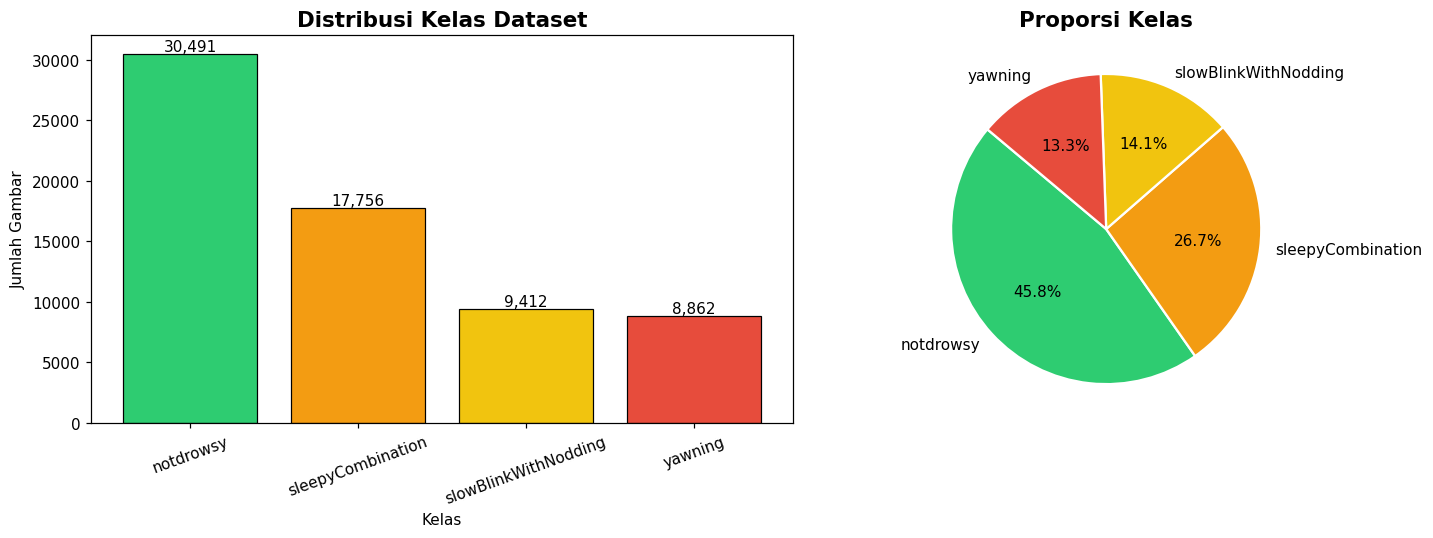


📊 Statistik:
   Total gambar     : 66,521
   Jumlah kelas     : 4
   Kelas terbanyak  : notdrowsy (30,491)
   Kelas tersedikit : yawning (8,862)


In [5]:
# ============================================================
# 3.1 Distribusi Kelas (Bar Chart)
# ============================================================
class_counts = df['label'].value_counts()
colors_bar   = ['#2ecc71','#f39c12','#f1c40f','#e74c3c','#9b59b6']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
bars = axes[0].bar(class_counts.index, class_counts.values,
                   color=colors_bar, edgecolor='black', linewidth=0.8)
axes[0].set_title('Distribusi Kelas Dataset', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Kelas')
axes[0].set_ylabel('Jumlah Gambar')
axes[0].tick_params(axis='x', rotation=20)
for bar in bars:
    h = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., h + 5,
                 f'{int(h):,}', ha='center', va='bottom', fontsize=10)

# Pie chart
axes[1].pie(class_counts.values, labels=class_counts.index, autopct='%1.1f%%',
            colors=colors_bar, startangle=140,
            wedgeprops={'edgecolor':'white','linewidth':1.5})
axes[1].set_title('Proporsi Kelas', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('class_distribution.png', bbox_inches='tight', dpi=120)
plt.show()

print(f'\n📊 Statistik:')
print(f'   Total gambar     : {len(df):,}')
print(f'   Jumlah kelas     : {df["label"].nunique()}')
print(f'   Kelas terbanyak  : {class_counts.idxmax()} ({class_counts.max():,})')
print(f'   Kelas tersedikit : {class_counts.idxmin()} ({class_counts.min():,})')

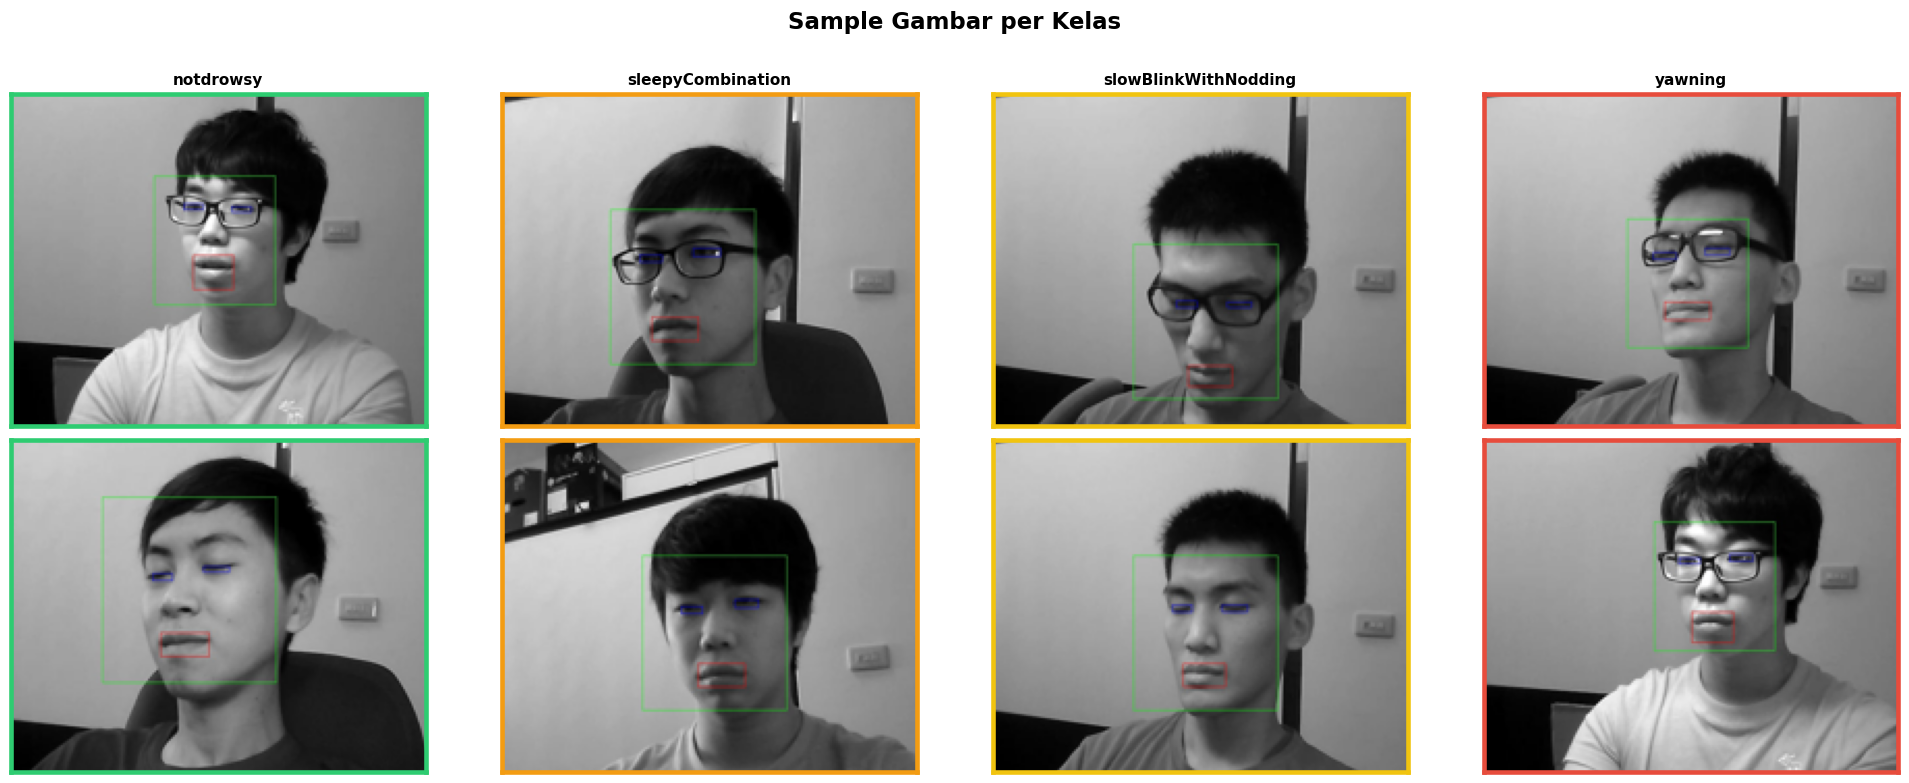

In [6]:
# ============================================================
# 3.2 Visualisasi Sample Gambar per Kelas
# ============================================================
fig, axes = plt.subplots(2, len(CFG['CLASSES'])-1, figsize=(18, 7))
classes = CFG['CLASSES'][1:]  # skip background

for col, cls in enumerate(classes):
    subset = df[df['label'] == cls]['image_path'].values
    for row in range(2):
        ax = axes[row][col]
        if len(subset) > row:
            try:
                img = Image.open(subset[row]).convert('RGB')
                img = img.resize((200, 160))
                ax.imshow(img)
                color = colors_bar[col]
                for spine in ax.spines.values():
                    spine.set_edgecolor(color)
                    spine.set_linewidth(3)
            except Exception:
                ax.text(0.5, 0.5, 'Error', ha='center', va='center')
        else:
            ax.text(0.5, 0.5, 'No image', ha='center', va='center')
        ax.set_xticks([]); ax.set_yticks([])
        if row == 0:
            ax.set_title(cls.replace('_','\n'), fontsize=10, fontweight='bold', pad=6)

plt.suptitle('Sample Gambar per Kelas', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('sample_images.png', bbox_inches='tight', dpi=120)
plt.show()

📐 Menganalisis properti gambar (sample 300)...


Analisis:   0%|          | 0/300 [00:00<?, ?it/s]

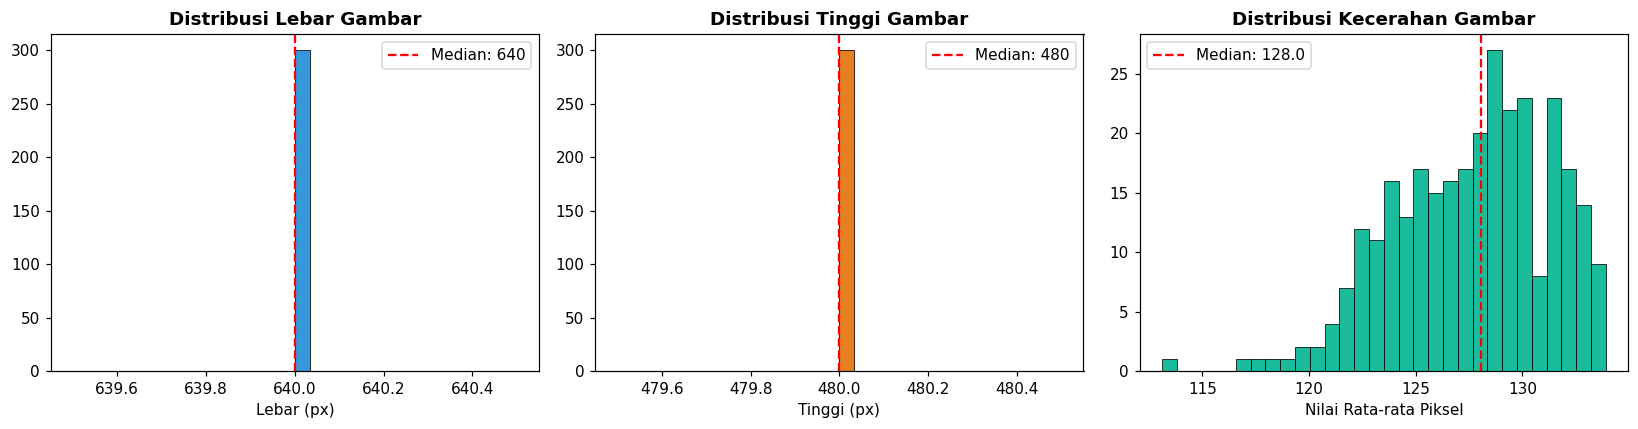


📐 Statistik Gambar:
   Resolusi umum : 640×480 px
   Kecerahan rata: 127.6 / 255


In [7]:
# ============================================================
# 3.3 Analisis Properti Gambar (Resolusi, Brightness)
# ============================================================
print('📐 Menganalisis properti gambar (sample 300)...')
SAMPLE_N = min(300, len(df))
sample_df = df.sample(SAMPLE_N, random_state=CFG['SEED'])

widths, heights, brights = [], [], []
for path in tqdm(sample_df['image_path'], desc='Analisis'):
    try:
        img = np.array(Image.open(path).convert('RGB'))
        widths.append(img.shape[1])
        heights.append(img.shape[0])
        brights.append(img.mean())
    except Exception:
        pass

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(widths, bins=30, color='#3498db', edgecolor='black', linewidth=0.5)
axes[0].set_title('Distribusi Lebar Gambar', fontweight='bold')
axes[0].set_xlabel('Lebar (px)')
axes[0].axvline(np.median(widths), color='red', linestyle='--', label=f'Median: {np.median(widths):.0f}')
axes[0].legend()

axes[1].hist(heights, bins=30, color='#e67e22', edgecolor='black', linewidth=0.5)
axes[1].set_title('Distribusi Tinggi Gambar', fontweight='bold')
axes[1].set_xlabel('Tinggi (px)')
axes[1].axvline(np.median(heights), color='red', linestyle='--', label=f'Median: {np.median(heights):.0f}')
axes[1].legend()

axes[2].hist(brights, bins=30, color='#1abc9c', edgecolor='black', linewidth=0.5)
axes[2].set_title('Distribusi Kecerahan Gambar', fontweight='bold')
axes[2].set_xlabel('Nilai Rata-rata Piksel')
axes[2].axvline(np.median(brights), color='red', linestyle='--', label=f'Median: {np.median(brights):.1f}')
axes[2].legend()

plt.tight_layout()
plt.savefig('image_properties.png', bbox_inches='tight', dpi=120)
plt.show()

print(f'\n📐 Statistik Gambar:')
print(f'   Resolusi umum : {int(np.median(widths))}×{int(np.median(heights))} px')
print(f'   Kecerahan rata: {np.mean(brights):.1f} / 255')

## BAGIAN 4: Data Preparation

In [8]:
# ============================================================
# 4.1 Generate Bounding Box dengan HSV Masking (Mendeteksi Kotak Hijau)
# ============================================================
import os
import cv2
import ast  # Tambahkan ini untuk membaca string list dari CSV
import pandas as pd
import numpy as np
from tqdm import tqdm

CLASS_TO_IDX = {cls: i for i, cls in enumerate(CFG['CLASSES'])}

# Tentukan path file anotasi di awal
anno_path = os.path.join(CFG['ANNO_DIR'], 'annotations.csv')

def detect_face_bbox(image_path):
    """
    Deteksi wajah dengan mendeteksi letak kotak hijau dan mengembalikan [x1,y1,x2,y2].
    Jika tidak ditemukan, return bbox seluruh gambar.
    """
    img = cv2.imread(image_path)
    if img is None:
        return None, None, None
    h, w = img.shape[:2]

    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    mask_green = cv2.inRange(hsv, np.array([40, 150, 150]), np.array([80, 255, 255]))
    mask_blue  = cv2.inRange(hsv, np.array([100, 150, 150]), np.array([140, 255, 255]))
    mask_red1  = cv2.inRange(hsv, np.array([0, 150, 150]), np.array([10, 255, 255]))
    mask_red2  = cv2.inRange(hsv, np.array([160, 150, 150]), np.array([179, 255, 255]))
    all_colors_mask = mask_green | mask_blue | mask_red1 | mask_red2

    y_indices, x_indices = np.where(all_colors_mask > 0)
    if len(x_indices) > 0 and len(y_indices) > 0:
        x1, x2 = int(np.min(x_indices)), int(np.max(x_indices))
        y1, y2 = int(np.min(y_indices)), int(np.max(y_indices))
        return [x1, y1, x2, y2], w, h

    # Fallback: bbox seluruh gambar
    return [0, 0, w-1, h-1], w, h

# ============================================================
# Cek apakah file anotasi sudah ada
# ============================================================
if os.path.exists(anno_path):
    print(f'✅ File anotasi ditemukan di {anno_path}')
    print('🔄 Memuat data dari cache (melewati proses deteksi wajah)...')

    # Baca CSV
    anno_df = pd.read_csv(anno_path)

    # Konversi kolom 'bbox' dari tipe string kembali ke bentuk list [x1, y1, x2, y2]
    if 'bbox' in anno_df.columns and isinstance(anno_df['bbox'].iloc[0], str):
        anno_df['bbox'] = anno_df['bbox'].apply(ast.literal_eval)

    print(f'✅ Berhasil memuat {len(anno_df):,} anotasi gambar.')

else:
    # Jika file belum ada, jalankan proses deteksi
    print('🔍 File anotasi belum ada. Memulai deteksi wajah untuk generate bounding box...')
    print(f'   Total gambar: {len(df):,}')
    print('   (Proses ini memakan sedikit waktu karena mendeteksi jutaan piksel)')

    annotations = []
    skipped = 0

    for _, row in tqdm(df.iterrows(), total=len(df), desc='Detecting faces via Green Box'):
        bbox, w, h = detect_face_bbox(row['image_path'])
        if bbox is None:
            skipped += 1
            continue
        annotations.append({
            'image_path': row['image_path'],
            'label'     : row['label'],
            'label_idx' : CLASS_TO_IDX[row['label']],
            'bbox'      : bbox,   # [x1, y1, x2, y2]
            'img_w'     : w,
            'img_h'     : h
        })

    anno_df = pd.DataFrame(annotations)
    print(f'\n✅ Anotasi selesai!')
    print(f'   Berhasil : {len(anno_df):,} gambar')
    print(f'   Dilewati : {skipped} gambar (tidak bisa dibaca)')

    # Pastikan folder tujuan tersedia sebelum menyimpan
    os.makedirs(CFG['ANNO_DIR'], exist_ok=True)

    # Simpan ke disk
    anno_df.to_csv(anno_path, index=False)
    print(f'   💾 Disimpan ke {anno_path}')

✅ File anotasi ditemukan di ./annotations/annotations.csv
🔄 Memuat data dari cache (melewati proses deteksi wajah)...
✅ Berhasil memuat 66,521 anotasi gambar.


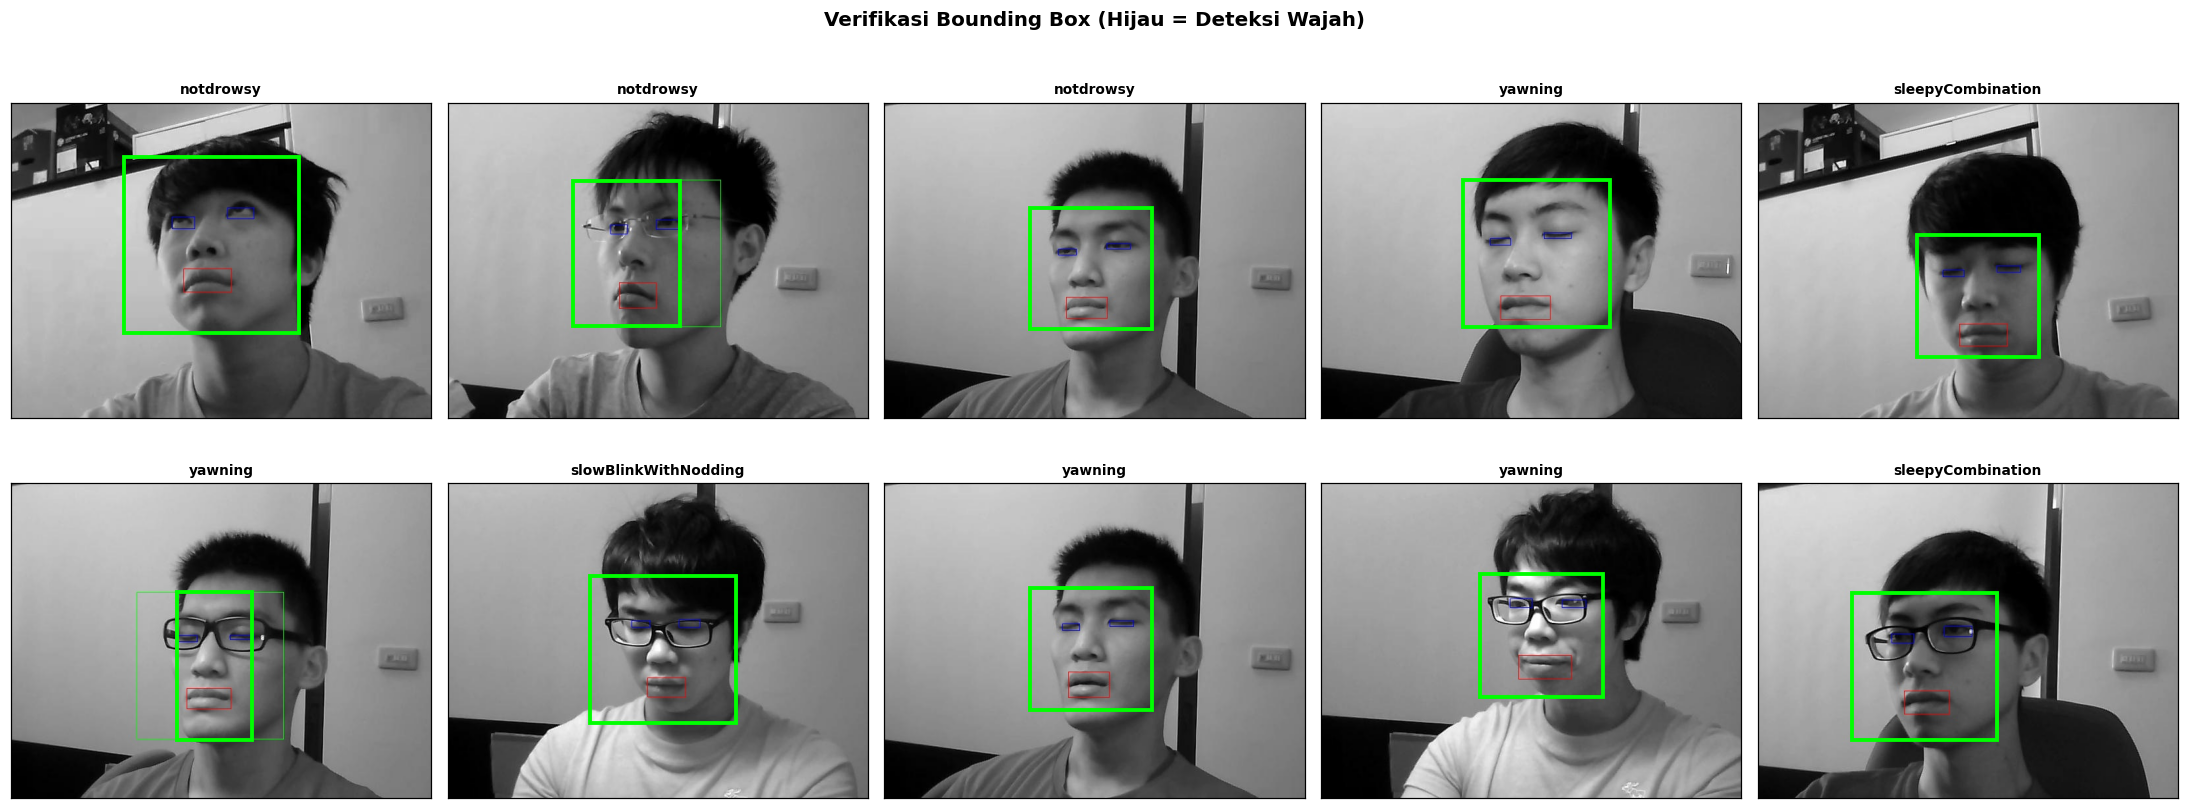

In [9]:
# ============================================================
# 4.2 Verifikasi Bounding Box
# ============================================================
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
sample_rows = anno_df.sample(10, random_state=CFG['SEED']).reset_index(drop=True)

for i, row in sample_rows.iterrows():
    ax = axes[i // 5][i % 5]
    try:
        img = np.array(Image.open(row['image_path']).convert('RGB'))
        ax.imshow(img)
        x1, y1, x2, y2 = row['bbox']
        rect = patches.Rectangle((x1, y1), x2-x1, y2-y1,
                                   linewidth=2.5, edgecolor='lime', facecolor='none')
        ax.add_patch(rect)
        ax.set_title(row['label'].replace('_','\n'), fontsize=9, fontweight='bold')
    except Exception as e:
        ax.text(0.5, 0.5, str(e), ha='center', va='center', fontsize=7)
    ax.set_xticks([]); ax.set_yticks([])

plt.suptitle('Verifikasi Bounding Box (Hijau = Deteksi Wajah)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('bbox_verification.png', bbox_inches='tight', dpi=120)
plt.show()

✂️  Split Dataset:
   Train : 49,890 gambar (75.0%)
   Val   : 9,978 gambar (15.0%)
   Test  : 6,653 gambar (10.0%)


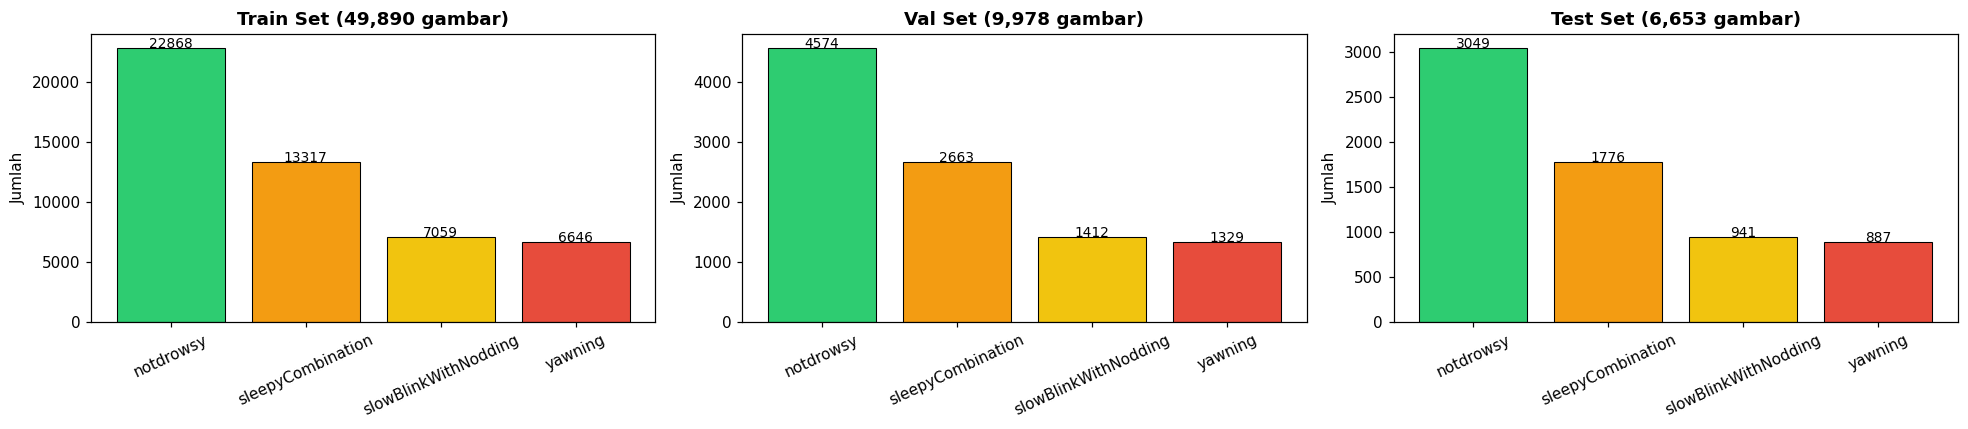

In [10]:
# ============================================================
# 4.3 Stratified Train / Val / Test Split
# ============================================================
from sklearn.model_selection import train_test_split

# Split 75% train, 15% val, 10% test (stratified per kelas)
train_df, temp_df = train_test_split(
    anno_df, test_size=(CFG['VAL_RATIO'] + CFG['TEST_RATIO']),
    stratify=anno_df['label'], random_state=CFG['SEED']
)
val_ratio_adj = CFG['VAL_RATIO'] / (CFG['VAL_RATIO'] + CFG['TEST_RATIO'])
val_df, test_df = train_test_split(
    temp_df, test_size=(1 - val_ratio_adj),
    stratify=temp_df['label'], random_state=CFG['SEED']
)

# Reset index
train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

print('✂️  Split Dataset:')
print(f'   Train : {len(train_df):,} gambar ({len(train_df)/len(anno_df)*100:.1f}%)')
print(f'   Val   : {len(val_df):,} gambar ({len(val_df)/len(anno_df)*100:.1f}%)')
print(f'   Test  : {len(test_df):,} gambar ({len(test_df)/len(anno_df)*100:.1f}%)')

# Visualisasi distribusi per split
fig, axes = plt.subplots(1, 3, figsize=(18, 4), sharey=False)
for ax, (name, data) in zip(axes, [('Train', train_df), ('Val', val_df), ('Test', test_df)]):
    vc = data['label'].value_counts()
    ax.bar(vc.index, vc.values, color=colors_bar[:len(vc)], edgecolor='black', linewidth=0.7)
    ax.set_title(f'{name} Set ({len(data):,} gambar)', fontweight='bold')
    ax.set_ylabel('Jumlah')
    ax.tick_params(axis='x', rotation=25)
    for p in ax.patches:
        ax.text(p.get_x()+p.get_width()/2, p.get_height()+2,
                str(int(p.get_height())), ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('split_distribution.png', bbox_inches='tight', dpi=120)
plt.show()

In [11]:
# ============================================================
# 4.4 Custom Dataset Class untuk Faster R-CNN
# ============================================================
class DrowsinessDataset(Dataset):
    """
    Dataset untuk Faster R-CNN.
    Output: (image_tensor, target_dict)
    target_dict = {
        'boxes'  : FloatTensor[N,4],   # x1,y1,x2,y2
        'labels' : Int64Tensor[N],     # kelas idx (1-based, 0=bg)
        'image_id': Int64Tensor[1]
    }
    """
    def __init__(self, df, transform=None, img_size=640):
        self.df        = df.reset_index(drop=True)
        self.transform = transform
        self.img_size  = img_size

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]

        img_bgr = cv2.imread(row['image_path'])

        # 1. HAPUS KOTAK WARNA (Inpainting) AGAR MODEL TIDAK CURANG
        hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
        mask_green = cv2.inRange(hsv, np.array([40, 150, 150]), np.array([80, 255, 255]))
        mask_blue  = cv2.inRange(hsv, np.array([100, 150, 150]), np.array([140, 255, 255]))
        mask_red1  = cv2.inRange(hsv, np.array([0, 150, 150]), np.array([10, 255, 255]))
        mask_red2  = cv2.inRange(hsv, np.array([160, 150, 150]), np.array([179, 255, 255]))

        all_colors_mask = mask_green | mask_blue | mask_red1 | mask_red2
        kernel = np.ones((3,3), np.uint8)
        all_colors_mask = cv2.dilate(all_colors_mask, kernel, iterations=1)

        img_cleaned = cv2.inpaint(img_bgr, all_colors_mask, 3, cv2.INPAINT_TELEA)

        # Convert ke RGB (format standar Albumentations & PyTorch)
        img = cv2.cvtColor(img_cleaned, cv2.COLOR_BGR2RGB)

        # Parse bbox dari dataframe
        if isinstance(row['bbox'], str):
            import ast
            bbox = ast.literal_eval(row['bbox'])
        else:
            bbox = row['bbox']
        x1, y1, x2, y2 = bbox
        label_idx = int(row['label_idx'])

        # Albumentations augmentation
        if self.transform:
            transformed = self.transform(
                image=img,
                bboxes=[[x1, y1, x2, y2]],
                labels=[label_idx]
            )
            img = transformed['image']          # sudah tensor HWC→CHW float/uint8
            bboxes = transformed['bboxes']
            labels = transformed['labels']
        else:
            img = torch.from_numpy(img).permute(2,0,1).float() / 255.0
            bboxes = [[x1, y1, x2, y2]]
            labels = [label_idx]

        if len(bboxes) == 0:
            # Augmentasi menghilangkan bbox → kembalikan seluruh gambar
            h, w = img.shape[-2], img.shape[-1]
            bboxes = [[0, 0, w, h]]
            labels = [label_idx]

        target = {
            'boxes'   : torch.tensor(bboxes, dtype=torch.float32),
            'labels'  : torch.tensor(labels, dtype=torch.int64),
            'image_id': torch.tensor([idx], dtype=torch.int64)
        }
        return img, target


print('✅ DrowsinessDataset class siap')


✅ DrowsinessDataset class siap


In [12]:
# ============================================================
# 4.5 Augmentasi Data
# ============================================================
IMG_SIZE = CFG['IMG_SIZE']

train_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
    A.HueSaturationValue(hue_shift_limit=15, sat_shift_limit=20, val_shift_limit=15, p=0.3),
    A.GaussianBlur(blur_limit=(3,7), p=0.3),
    A.RandomGamma(gamma_limit=(80,120), p=0.3),
    A.CLAHE(clip_limit=4.0, tile_grid_size=(8,8), p=0.3),  # Penting untuk kondisi siang/malam
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1, rotate_limit=10, p=0.4),
    A.Normalize(mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225)),
    ToTensorV2()
], bbox_params=A.BboxParams(format='pascal_voc', label_fields=['labels'],
                             min_visibility=0.3))

val_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225)),
    ToTensorV2()
], bbox_params=A.BboxParams(format='pascal_voc', label_fields=['labels'],
                             min_visibility=0.3))

# ============================================================
# 4.6 Buat DataLoader
# ============================================================
def collate_fn(batch):
    return tuple(zip(*batch))

train_dataset = DrowsinessDataset(train_df, transform=train_transform, img_size=IMG_SIZE)
val_dataset   = DrowsinessDataset(val_df,   transform=val_transform,   img_size=IMG_SIZE)
test_dataset  = DrowsinessDataset(test_df,  transform=val_transform,   img_size=IMG_SIZE)

train_loader = DataLoader(train_dataset, batch_size=CFG['BATCH_SIZE'],
                          shuffle=True,  num_workers=CFG['NUM_WORKERS'],
                          collate_fn=collate_fn, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=CFG['BATCH_SIZE'],
                          shuffle=False, num_workers=CFG['NUM_WORKERS'],
                          collate_fn=collate_fn, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=1,
                          shuffle=False, num_workers=0,
                          collate_fn=collate_fn)

print('✅ DataLoader siap:')
print(f'   Train batches : {len(train_loader)}')
print(f'   Val batches   : {len(val_loader)}')
print(f'   Test batches  : {len(test_loader)}')

# Verifikasi satu batch
imgs, targets = next(iter(train_loader))
print(f'\n🔍 Bentuk satu batch:')
print(f'   Gambar[0] shape: {imgs[0].shape}')
print(f'   BBox[0]        : {targets[0]["boxes"]}')
print(f'   Label[0]       : {targets[0]["labels"]} → {[CFG["CLASSES"][l] for l in targets[0]["labels"].tolist()]}')

✅ DataLoader siap:
   Train batches : 12473
   Val batches   : 2495
   Test batches  : 6653

🔍 Bentuk satu batch:
   Gambar[0] shape: torch.Size([3, 640, 640])
   BBox[0]        : tensor([[216.0000, 157.3333, 439.0000, 454.6667]])
   Label[0]       : tensor([2]) → ['sleepyCombination']


## BAGIAN 5: Training Model: Faster R-CNN

Menggunakan **Faster R-CNN dengan ResNet-50 + FPN** yang telah di-pretrain pada COCO.
Kita hanya mengganti layer classifier terakhir sesuai jumlah kelas kita.

In [13]:
# ============================================================
# 5.1 Bangun Model Faster R-CNN
# ============================================================
def build_faster_rcnn(num_classes, score_thresh=0.5):
    """
    Load Faster R-CNN pretrained COCO, ganti head classifier.
    num_classes termasuk background (jadi 6 untuk 5 kelas).
    """
    # Load pretrained weights COCO
    model = fasterrcnn_resnet50_fpn(
        weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT
    )

    # Ganti kepala klasifikasi & regresi box
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

    # Sesuaikan threshold
    model.roi_heads.score_thresh   = score_thresh
    model.roi_heads.nms_thresh     = CFG['NMS_THRESH']
    model.roi_heads.detections_per_img = 10

    return model

model = build_faster_rcnn(CFG['NUM_CLASSES'], CFG['SCORE_THRESH'])
model = model.to(DEVICE)

# Hitung parameter
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'🏗️  Model: Faster R-CNN (ResNet-50 + FPN)')
print(f'   Total params    : {total_params:,}')
print(f'   Trainable params: {trainable_params:,}')
print(f'   Num classes     : {CFG["NUM_CLASSES"]} (bg + {CFG["NUM_CLASSES"]-1} kelas)')

# ============================================================
# 5.2 Optimizer & Scheduler
# ============================================================
params = [p for p in model.parameters() if p.requires_grad]
optimizer = optim.SGD(
    params, lr=CFG['LR'],
    momentum=CFG['MOMENTUM'],
    weight_decay=CFG['WEIGHT_DECAY']
)
lr_scheduler = optim.lr_scheduler.StepLR(
    optimizer, step_size=CFG['LR_STEP_SIZE'], gamma=CFG['LR_GAMMA']
)

print(f'\n⚙️  Optimizer: SGD (lr={CFG["LR"]}, momentum={CFG["MOMENTUM"]})')
print(f'   Scheduler: StepLR (step={CFG["LR_STEP_SIZE"]}, gamma={CFG["LR_GAMMA"]})')

Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:01<00:00, 160MB/s]


🏗️  Model: Faster R-CNN (ResNet-50 + FPN)
   Total params    : 41,314,536
   Trainable params: 41,092,136
   Num classes     : 5 (bg + 4 kelas)

⚙️  Optimizer: SGD (lr=0.005, momentum=0.9)
   Scheduler: StepLR (step=7, gamma=0.1)


In [ ]:
import os
import glob
import re
import time
import json
import torch
from collections import defaultdict
from tqdm import tqdm
from torchmetrics.detection.mean_ap import MeanAveragePrecision

# ============================================================
# 5.3 Training Loop
# ============================================================
def train_one_epoch(model, loader, optimizer, device, epoch):
    model.train()
    total_loss = 0
    loss_dict_total = defaultdict(float)

    pbar = tqdm(loader, desc=f'Epoch {epoch:>2} [Train]', leave=False)
    for step, (images, targets) in enumerate(pbar):
        images  = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k,v in t.items()} for t in targets]

        loss_dict = model(images, targets)
        losses    = sum(loss for loss in loss_dict.values())

        optimizer.zero_grad()
        losses.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()

        total_loss += losses.item()
        for k, v in loss_dict.items():
            loss_dict_total[k] += v.item()
        pbar.set_postfix({'loss': f'{losses.item():.4f}'})

        # Simpan checkpoint setiap 400 step ke Google Drive
        if (step + 1) % 400 == 0:
            drive_path = '/content/drive/MyDrive/checkpoints'
            os.makedirs(drive_path, exist_ok=True)
            ckpt_path = os.path.join(drive_path, f'epoch_{epoch:03d}_step_{step+1}.pth')
            # MODIFIKASI: Simpan juga state optimizer agar resume training mulus
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict()
            }, ckpt_path)

    n = len(loader)
    return total_loss / n, {k: v/n for k,v in loss_dict_total.items()}


@torch.no_grad()
def evaluate_epoch(model, loader, device, epoch):
    model.eval()
    metric = MeanAveragePrecision(iou_type='bbox')

    pbar = tqdm(loader, desc=f'Epoch {epoch:>2} [Val]  ', leave=False)
    for images, targets in pbar:
        images = [img.to(device) for img in images]
        preds  = model(images)

        preds_cpu   = [{k: v.cpu() for k,v in p.items()} for p in preds]
        targets_cpu = [{k: v.cpu() for k,v in t.items()} for t in targets]
        metric.update(preds_cpu, targets_cpu)

    result = metric.compute()
    return result


# ============================================================
# 5.4 Logika Resume Training (BARU)
# ============================================================
drive_path = '/content/drive/MyDrive/checkpoints/'
start_epoch = 1

print('🔍 Mengecek checkpoint terakhir di Google Drive...')
if os.path.exists(drive_path):
    # Cari semua file .pth di folder checkpoints
    checkpoints = glob.glob(os.path.join(drive_path, 'epoch_*.pth'))

    if checkpoints:
        # Ambil file yang paling baru dimodifikasi
        latest_ckpt = max(checkpoints, key=os.path.getmtime)
        print(f'🔄 Ditemukan checkpoint: {os.path.basename(latest_ckpt)}')

        # Muat checkpoint
        checkpoint = torch.load(latest_ckpt, map_location=DEVICE)

        # Cek apakah format checkpoint berupa dictionary (format baru) atau state_dict biasa (format lama)
        if isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint:
            model.load_state_dict(checkpoint['model_state_dict'])
            if 'optimizer_state_dict' in checkpoint:
                optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        else:
            model.load_state_dict(checkpoint)

        # Tentukan dari epoch mana kita harus lanjut dengan regex nama file
        basename = os.path.basename(latest_ckpt)
        match_full = re.search(r'epoch_(\d+)\.pth', basename)
        match_step = re.search(r'epoch_(\d+)_step_\d+\.pth', basename)

        if match_full:
            # Jika file adalah epoch_005.pth, berarti epoch 5 sudah selesai, mulai dari epoch 6
            start_epoch = int(match_full.group(1)) + 1
        elif match_step:
            # Jika file adalah epoch_005_step_400.pth, berarti gagal di tengah epoch 5, ulang epoch 5
            start_epoch = int(match_step.group(1))

        print(f'✅ Berhasil memuat model! Akan melanjutkan training dari Epoch {start_epoch}')
    else:
        print('ℹ️ Tidak ada file checkpoint ditemukan. Memulai training dari awal.')
else:
    print('ℹ️ Folder checkpoints belum ada. Memulai training dari awal.')


# ============================================================
# 5.5 Training Loop Utama
# ============================================================
history = {
    'train_loss': [], 'val_map': [], 'val_map_50': [],
    'lr': [], 'loss_classifier': [], 'loss_box_reg': [],
    'loss_objectness': [], 'loss_rpn_box_reg': []
}

best_map   = 0.0
best_epoch = 0
start_time = time.time()

print('\n🚀 Memulai Training Faster R-CNN...')
print(f'   Epochs Target : {CFG["NUM_EPOCHS"]} (Mulai dari {start_epoch})')
print(f'   Batch Size    : {CFG["BATCH_SIZE"]}')
print(f'   Device        : {DEVICE}')
print('─' * 65)
print(f"{'Epoch':>6} | {'Train Loss':>11} | {'mAP@.5:.95':>11} | {'mAP@.50':>9} | {'LR':>8}")
print('─' * 65)

# MODIFIKASI: Gunakan start_epoch di range
for epoch in range(start_epoch, CFG['NUM_EPOCHS'] + 1):
    # Train
    train_loss, loss_components = train_one_epoch(
        model, train_loader, optimizer, DEVICE, epoch
    )
    # Evaluate
    val_metrics = evaluate_epoch(model, val_loader, DEVICE, epoch)
    lr_scheduler.step()

    current_lr  = optimizer.param_groups[0]['lr']
    val_map     = float(val_metrics['map'])
    val_map50   = float(val_metrics['map_50'])

    # Simpan history
    history['train_loss'].append(train_loss)
    history['val_map'].append(val_map)
    history['val_map_50'].append(val_map50)
    history['lr'].append(current_lr)
    for k in ['loss_classifier','loss_box_reg','loss_objectness','loss_rpn_box_reg']:
        history[k].append(loss_components.get(k, 0.0))

    # Simpan best model
    is_best = val_map > best_map
    if is_best:
        best_map   = val_map
        best_epoch = epoch
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'best_map': best_map,
            'cfg': CFG
        }, os.path.join(CFG['CHECKPOINT_DIR'], 'best_model.pth'))

    marker = '★ BEST' if is_best else ''
    print(f'{epoch:>6} | {train_loss:>11.4f} | {val_map:>11.4f} | {val_map50:>9.4f} | {current_lr:>8.6f}  {marker}')

    # Simpan checkpoint setiap 1 epoch
    if epoch % 1 == 0:
        os.makedirs(drive_path, exist_ok=True)
        ckpt_path = os.path.join(drive_path, f'epoch_{epoch:03d}.pth')
        # MODIFIKASI: Simpan sebagai dictionary juga di sini
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict()
        }, ckpt_path)
        # Opsi simpan ke directory lokal jika dibutuhkan
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict()
        }, os.path.join(CFG['CHECKPOINT_DIR'], f'epoch_{epoch:03d}.pth'))

elapsed = time.time() - start_time
print('─' * 65)
print(f'✅ Training selesai dalam {elapsed/60:.1f} menit')
print(f'   Best mAP@.5:.95 = {best_map:.4f} (epoch {best_epoch})')

# Simpan history
with open(os.path.join(CFG['LOG_DIR'], 'history.json'), 'w') as f:
    json.dump(history, f)

🔍 Mengecek checkpoint terakhir di Google Drive...
🔄 Ditemukan checkpoint: epoch_002_step_400.pth
✅ Berhasil memuat model! Akan melanjutkan training dari Epoch 2

🚀 Memulai Training Faster R-CNN...
   Epochs Target : 20 (Mulai dari 2)
   Batch Size    : 4
   Device        : cuda
─────────────────────────────────────────────────────────────────
 Epoch |  Train Loss |  mAP@.5:.95 |   mAP@.50 |       LR
─────────────────────────────────────────────────────────────────


Epoch  2 [Train]:   1%|          | 70/12473 [01:05<3:15:41,  1.06it/s, loss=0.0222]

## BAGIAN 6: Evaluasi Model

In [ ]:
# ============================================================
# 6.1 Loss & mAP Curves
# ============================================================
epochs_x = list(range(1, len(history['train_loss'])+1))

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Plot 1: Total Training Loss
ax = axes[0][0]
ax.plot(epochs_x, history['train_loss'], 'b-o', linewidth=2, markersize=4)
ax.set_title('Total Training Loss', fontweight='bold')
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.grid(True, alpha=0.3)

# Plot 2: Loss Components
ax = axes[0][1]
for lbl, key, col in [
    ('Classifier',  'loss_classifier',   '#e74c3c'),
    ('Box Reg',     'loss_box_reg',       '#3498db'),
    ('Objectness',  'loss_objectness',    '#2ecc71'),
    ('RPN Box Reg', 'loss_rpn_box_reg',   '#f39c12')
]:
    ax.plot(epochs_x, history[key], '-o', label=lbl, color=col, linewidth=1.5, markersize=3)
ax.set_title('Loss Komponen', fontweight='bold')
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

# Plot 3: mAP
ax = axes[1][0]
ax.plot(epochs_x, history['val_map'],    'g-o', linewidth=2, markersize=4, label='mAP@.5:.95')
ax.plot(epochs_x, history['val_map_50'], 'b--s', linewidth=2, markersize=4, label='mAP@.50')
best_ep = np.argmax(history['val_map'])
ax.axvline(x=best_ep+1, color='red', linestyle=':', linewidth=1.5, label=f'Best Epoch={best_ep+1}')
ax.scatter([best_ep+1], [history['val_map'][best_ep]], color='red', zorder=5, s=100)
ax.set_title('Validation mAP', fontweight='bold')
ax.set_xlabel('Epoch'); ax.set_ylabel('mAP')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

# Plot 4: Learning Rate
ax = axes[1][1]
ax.plot(epochs_x, history['lr'], 'r-', linewidth=2)
ax.set_title('Learning Rate Schedule', fontweight='bold')
ax.set_xlabel('Epoch'); ax.set_ylabel('LR')
ax.set_yscale('log'); ax.grid(True, alpha=0.3)

plt.suptitle('Training Metrics — Faster R-CNN Drowsiness Detection',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('training_curves.png', bbox_inches='tight', dpi=120)
plt.show()

In [ ]:
# ============================================================
# 6.2 Evaluasi pada Test Set (Load Best Model)
# ============================================================
# Load model terbaik
checkpoint = torch.load(
    os.path.join(CFG['CHECKPOINT_DIR'], 'best_model.pth'),
    map_location=DEVICE
)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()
print(f'✅ Model terbaik dimuat (epoch {checkpoint["epoch"]}, mAP={checkpoint["best_map"]:.4f})')

# Evaluasi mAP pada test set
metric_test = MeanAveragePrecision(iou_type='bbox',
                                    class_metrics=True)

all_pred_labels = []
all_true_labels = []

with torch.no_grad():
    for images, targets in tqdm(test_loader, desc='Evaluasi Test Set'):
        images = [img.to(DEVICE) for img in images]
        preds  = model(images)

        preds_cpu   = [{k: v.cpu() for k,v in p.items()} for p in preds]
        targets_cpu = [{k: v.cpu() for k,v in t.items()} for t in targets]
        metric_test.update(preds_cpu, targets_cpu)

        # Untuk confusion matrix: ambil prediksi dengan skor tertinggi
        for pred, tgt in zip(preds_cpu, targets_cpu):
            true_lbl = tgt['labels'][0].item() if len(tgt['labels']) > 0 else 0
            if len(pred['scores']) > 0:
                best_idx = pred['scores'].argmax().item()
                pred_lbl = pred['labels'][best_idx].item()
            else:
                pred_lbl = 0
            all_true_labels.append(true_lbl)
            all_pred_labels.append(pred_lbl)

test_result = metric_test.compute()

print('\n📊 Hasil Evaluasi Test Set:')
print(f'   mAP@.5:.95     : {test_result["map"]:.4f}')
print(f'   mAP@.50        : {test_result["map_50"]:.4f}')
print(f'   mAP@.75        : {test_result["map_75"]:.4f}')
print(f'   mAP (small)    : {test_result["map_small"]:.4f}')
print(f'   mAP (medium)   : {test_result["map_medium"]:.4f}')
print(f'   mAP (large)    : {test_result["map_large"]:.4f}')

# Per kelas
if 'map_per_class' in test_result and test_result['map_per_class'] is not None:
    print('\n   mAP per kelas:')
    for cls, ap in zip(CFG['CLASSES'][1:], test_result['map_per_class']):
        print(f'     {cls:20s}: {float(ap):.4f}')

In [ ]:
# ============================================================
# 6.3 Confusion Matrix
# ============================================================
# Filter hanya kelas 1-5 (skip background)
valid_mask = [(t > 0 and p > 0) for t, p in zip(all_true_labels, all_pred_labels)]
true_filt  = [all_true_labels[i] for i, v in enumerate(valid_mask) if v]
pred_filt  = [all_pred_labels[i] for i, v in enumerate(valid_mask) if v]
class_names = CFG['CLASSES'][1:]
class_idxs  = list(range(1, len(CFG['CLASSES'])))

cm = confusion_matrix(true_filt, pred_filt, labels=class_idxs)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Raw count
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            ax=axes[0], linewidths=0.5, linecolor='gray')
axes[0].set_title('Confusion Matrix (Count)', fontweight='bold')
axes[0].set_xlabel('Prediksi'); axes[0].set_ylabel('Aktual')
axes[0].tick_params(axis='x', rotation=30)

# Normalized
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Greens',
            xticklabels=class_names, yticklabels=class_names,
            ax=axes[1], linewidths=0.5, linecolor='gray',
            vmin=0, vmax=1)
axes[1].set_title('Confusion Matrix (Normalized)', fontweight='bold')
axes[1].set_xlabel('Prediksi'); axes[1].set_ylabel('Aktual')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('confusion_matrix.png', bbox_inches='tight', dpi=120)
plt.show()

# Classification Report
print('\n📋 Classification Report:')
print(classification_report(
    true_filt, pred_filt,
    labels=class_idxs,
    target_names=class_names
))

In [ ]:
# ============================================================
# 6.4 Visualisasi Prediksi pada Test Set
# ============================================================
MEAN = np.array([0.485, 0.456, 0.406])
STD  = np.array([0.229, 0.224, 0.225])

def denormalize(tensor):
    img = tensor.permute(1,2,0).numpy()
    img = img * STD + MEAN
    img = np.clip(img * 255, 0, 255).astype(np.uint8)
    return img

def draw_predictions(img_np, pred, classes, score_thresh=0.3):
    img_bgr = cv2.cvtColor(img_np, cv2.COLOR_RGB2BGR)
    for box, label, score in zip(pred['boxes'], pred['labels'], pred['scores']):
        if score < score_thresh:
            continue
        x1,y1,x2,y2 = [int(c) for c in box]
        cls_name = classes[label.item()] if label.item() < len(classes) else 'unknown'
        color = CLASS_COLORS.get(cls_name, (200,200,200))
        cv2.rectangle(img_bgr, (x1,y1), (x2,y2), color, 2)
        label_str = f'{cls_name} {score:.2f}'
        (tw, th), _ = cv2.getTextSize(label_str, cv2.FONT_HERSHEY_SIMPLEX, 0.5, 1)
        cv2.rectangle(img_bgr, (x1, y1-th-8), (x1+tw+4, y1), color, -1)
        cv2.putText(img_bgr, label_str, (x1+2, y1-4),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255,255,255), 1)
    return cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# Ambil 10 sampel dari test set
fig, axes = plt.subplots(2, 5, figsize=(22, 9))
model.eval()
sample_iter = iter(test_loader)

with torch.no_grad():
    for i in range(10):
        ax = axes[i//5][i%5]
        try:
            imgs, tgts = next(sample_iter)
            img_tensor = imgs[0]
            preds = model([img_tensor.to(DEVICE)])
            pred_cpu = {k: v.cpu() for k,v in preds[0].items()}

            img_np   = denormalize(img_tensor.cpu())
            img_draw = draw_predictions(img_np, pred_cpu, CFG['CLASSES'])

            ax.imshow(img_draw)
            true_lbl = CFG['CLASSES'][tgts[0]['labels'][0].item()]
            ax.set_title(f'GT: {true_lbl}', fontsize=9, fontweight='bold', color='navy')
        except StopIteration:
            ax.text(0.5, 0.5, 'No data', ha='center', va='center')
        ax.set_xticks([]); ax.set_yticks([])

plt.suptitle('Prediksi Faster R-CNN pada Test Set', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('test_predictions.png', bbox_inches='tight', dpi=120)
plt.show()

## BAGIAN 7: Real-Time Inference

Sistem akan membuka webcam dan mendeteksi kantuk secara **real-time** dengan:
- Bounding box berwarna per kelas
- Status alert (⚠️ WARNING saat drowsy terdeteksi)
- FPS counter
- Dashboard info

In [ ]:
# ============================================================
# 7.1 Utility Fungsi Inference
# ============================================================
import torchvision.transforms.functional as TF

DROWSY_CLASSES = {'yawning', 'slow_blink', 'falling_asleep', 'nodding'}

def preprocess_frame(frame_bgr, img_size=640):
    """
    Preprocessing frame dari webcam untuk inferensi.
    Mengembalikan tensor yang siap dimasukkan ke model.
    """
    frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
    frame_pil = Image.fromarray(frame_rgb)
    frame_pil = frame_pil.resize((img_size, img_size))

    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225))
    ])
    return transform(frame_pil), frame_bgr.shape


def draw_detections(frame_bgr, preds, orig_shape, classes,
                    score_thresh=0.4, model_size=640):
    """
    Gambar bounding box & label di atas frame asli.
    Kembalikan (frame_annotated, is_drowsy, drowsy_class).
    """
    h_orig, w_orig = orig_shape[:2]
    scale_x = w_orig / model_size
    scale_y = h_orig / model_size

    is_drowsy    = False
    drowsy_class = None
    max_score    = 0

    for box, label, score in zip(preds['boxes'], preds['labels'], preds['scores']):
        if score < score_thresh:
            continue
        x1 = int(box[0].item() * scale_x)
        y1 = int(box[1].item() * scale_y)
        x2 = int(box[2].item() * scale_x)
        y2 = int(box[3].item() * scale_y)

        cls_idx  = label.item()
        cls_name = classes[cls_idx] if cls_idx < len(classes) else 'unknown'
        color_rgb = CLASS_COLORS.get(cls_name, (200,200,200))
        color_bgr = color_rgb[::-1]  # RGB→BGR untuk OpenCV

        if cls_name in DROWSY_CLASSES and score > max_score:
            is_drowsy    = True
            drowsy_class = cls_name
            max_score    = score.item()

        # Gambar bounding box
        thickness = 3 if cls_name in DROWSY_CLASSES else 2
        cv2.rectangle(frame_bgr, (x1,y1), (x2,y2), color_bgr, thickness)

        # Label latar
        label_text = f'{cls_name.replace("_"," ")} {score:.2f}'
        (tw, th), _ = cv2.getTextSize(label_text, cv2.FONT_HERSHEY_DUPLEX, 0.55, 1)
        cv2.rectangle(frame_bgr, (x1, max(0,y1-th-10)), (x1+tw+6, y1), color_bgr, -1)
        cv2.putText(frame_bgr, label_text,
                    (x1+3, max(10, y1-4)),
                    cv2.FONT_HERSHEY_DUPLEX, 0.55, (255,255,255), 1, cv2.LINE_AA)

    return frame_bgr, is_drowsy, drowsy_class


def draw_hud(frame, fps, is_drowsy, drowsy_class, alert_duration):
    """
    Gambar HUD (Head-Up Display) di atas frame:
    - FPS counter
    - Status waspada / mengantuk
    - Alert overlay
    """
    h, w = frame.shape[:2]

    # FPS
    cv2.putText(frame, f'FPS: {fps:.1f}',
                (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0,255,255), 2)

    # Status bar
    if is_drowsy:
        status_text  = f'⚠ DROWSY: {drowsy_class.replace("_"," ").upper()}'
        status_color = (0, 0, 220)   # Merah (BGR)
        # Alert overlay merah semi-transparan di tepi
        overlay = frame.copy()
        cv2.rectangle(overlay, (0,0), (w,h), (0,0,180), -1)
        alpha = min(0.25, 0.05 * alert_duration)
        cv2.addWeighted(overlay, alpha, frame, 1-alpha, 0, frame)
        # Border merah tebal
        bw = 8
        cv2.rectangle(frame, (0,0), (w-1,h-1), (0,0,220), bw)
    else:
        status_text  = '✔ ALERT — Normal Driving'
        status_color = (0, 200, 0)   # Hijau (BGR)

    # Gambar status bar
    bar_h = 40
    cv2.rectangle(frame, (0, h-bar_h), (w, h), (30,30,30), -1)
    cv2.putText(frame, status_text,
                (10, h-12), cv2.FONT_HERSHEY_DUPLEX, 0.65, status_color, 2)

    # Watermark
    cv2.putText(frame, 'Faster R-CNN Drowsiness Detection',
                (w-360, 25), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (200,200,200), 1)

    return frame

print('✅ Fungsi inference real-time siap!')

In [ ]:
# ============================================================
# 7.2 Real-Time Detection — Webcam
# ============================================================
# Pastikan model dalam eval mode
model.eval()

# ──── PARAMETER ────────────────────────────────────────────
SCORE_THRESHOLD  = 0.45    # min confidence untuk ditampilkan
DROWSY_ALERT_SEC = 2.5     # durasi alert berturut-turut (detik)
CAMERA_INDEX     = 0       # 0 = webcam default
SAVE_VIDEO       = True    # simpan hasil ke file
OUTPUT_VIDEO     = 'drowsiness_realtime.avi'
# ───────────────────────────────────────────────────────────

cap = cv2.VideoCapture(CAMERA_INDEX)
if not cap.isOpened():
    print('❌ Webcam tidak ditemukan! Pastikan kamera tersambung.')
    print('   Coba ganti CAMERA_INDEX = 1 atau gunakan Mode Demo di bawah.')
else:
    cap.set(cv2.CAP_PROP_FRAME_WIDTH,  1280)
    cap.set(cv2.CAP_PROP_FRAME_HEIGHT, 720)

    W = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    H = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    print(f'📷 Webcam dibuka: {W}×{H}')

    # Video writer
    writer = None
    if SAVE_VIDEO:
        fourcc = cv2.VideoWriter_fourcc(*'XVID')
        writer = cv2.VideoWriter(OUTPUT_VIDEO, fourcc, 20, (W, H))

    fps_vals      = []
    alert_counter = 0.0
    drowsy_history = []   # history deteksi
    frame_count   = 0

    print('\n🎥 Memulai deteksi real-time...')
    print('   Tekan [Q] untuk keluar')
    print('   Tekan [S] untuk screenshot')

    try:
        while True:
            t0    = time.time()
            ret, frame = cap.read()
            if not ret:
                print('⚠️  Frame tidak terbaca, mencoba lagi...')
                continue

            frame_count += 1
            orig_shape = frame.shape

            # Preprocessing
            img_tensor, _ = preprocess_frame(frame, CFG['IMG_SIZE'])

            # Inferensi
            with torch.no_grad():
                pred = model([img_tensor.to(DEVICE)])
            pred_cpu = {k: v.cpu() for k,v in pred[0].items()}

            # Gambar deteksi
            frame, is_drowsy, drowsy_class = draw_detections(
                frame, pred_cpu, orig_shape, CFG['CLASSES'],
                score_thresh=SCORE_THRESHOLD, model_size=CFG['IMG_SIZE']
            )

            # Update alert counter
            if is_drowsy:
                alert_counter = min(alert_counter + 1, DROWSY_ALERT_SEC * 30)
            else:
                alert_counter = max(0, alert_counter - 2)

            # Hitung FPS
            elapsed = time.time() - t0
            fps = 1.0 / max(elapsed, 1e-5)
            fps_vals.append(fps)
            if len(fps_vals) > 30:
                fps_vals.pop(0)
            avg_fps = np.mean(fps_vals)

            # Gambar HUD
            trigger_alert = alert_counter > (DROWSY_ALERT_SEC * 30 * 0.5)
            frame = draw_hud(frame, avg_fps, trigger_alert,
                             drowsy_class or '', alert_counter)

            # Simpan frame
            if writer:
                writer.write(frame)

            # Tampilkan di notebook (setiap 5 frame agar tidak terlalu berat)
            if frame_count % 5 == 0:
                frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                from IPython.display import display, clear_output
                from PIL import Image as PILImg
                import io
                pil_img = PILImg.fromarray(frame_rgb)
                pil_img = pil_img.resize((800, int(800 * H/W)))
                buf = io.BytesIO()
                pil_img.save(buf, format='JPEG', quality=80)
                buf.seek(0)
                from IPython.display import Image as IPyImage
                clear_output(wait=True)
                display(IPyImage(data=buf.read()))

            # Stop setelah 300 frame untuk demo notebook
            # Hapus baris ini untuk running terus-menerus
            if frame_count >= 300:
                print(f'\n⏹  Demo selesai ({frame_count} frame)')
                break

    except KeyboardInterrupt:
        print('\n⏹  Dihentikan oleh pengguna')

    finally:
        cap.release()
        if writer:
            writer.release()
        print(f'\n📊 Statistik Sesi:')
        print(f'   Total frame diproses : {frame_count}')
        print(f'   Rata-rata FPS        : {np.mean(fps_vals):.1f}')
        if SAVE_VIDEO:
            print(f'   Video tersimpan ke   : {OUTPUT_VIDEO}')

In [ ]:
# ============================================================
# 7.3 Mode Demo — Inference pada Gambar dari Test Set
#     (Gunakan ini jika tidak ada webcam)
# ============================================================
model.eval()

# Ambil 6 gambar acak dari test set
demo_samples = test_df.sample(6, random_state=99).reset_index(drop=True)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for i, row in demo_samples.iterrows():
    ax = axes[i//3][i%3]
    try:
        frame_bgr = cv2.imread(row['image_path'])
        if frame_bgr is None:
            raise FileNotFoundError
        orig_shape = frame_bgr.shape

        img_tensor, _ = preprocess_frame(frame_bgr, CFG['IMG_SIZE'])
        with torch.no_grad():
            pred = model([img_tensor.to(DEVICE)])
        pred_cpu = {k: v.cpu() for k,v in pred[0].items()}

        frame_out, is_drowsy, drowsy_class = draw_detections(
            frame_bgr.copy(), pred_cpu, orig_shape,
            CFG['CLASSES'], score_thresh=0.35
        )

        # Tambahkan status bar ke gambar
        h, w = frame_out.shape[:2]
        bar_h = 40
        cv2.rectangle(frame_out, (0, h-bar_h), (w, h), (30,30,30), -1)
        status_str  = '⚠ DROWSY' if is_drowsy else '✔ ALERT'
        status_col  = (0,0,200) if is_drowsy else (0,200,0)
        cv2.putText(frame_out, f'GT: {row["label"]} | Pred: {status_str}',
                    (8, h-12), cv2.FONT_HERSHEY_SIMPLEX, 0.55, status_col, 1)

        frame_rgb = cv2.cvtColor(frame_out, cv2.COLOR_BGR2RGB)
        ax.imshow(frame_rgb)

        title_color = 'red' if is_drowsy else 'green'
        ax.set_title(f'GT: {row["label"]}', fontsize=10,
                     fontweight='bold', color=title_color)

    except Exception as e:
        ax.text(0.5, 0.5, f'Error:\n{e}', ha='center', va='center', fontsize=8)

    ax.set_xticks([]); ax.set_yticks([])

plt.suptitle('Demo Deteksi Kantuk — Faster R-CNN\n(Hijau=Waspada | Merah=Mengantuk)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('demo_predictions.png', bbox_inches='tight', dpi=120)
plt.show()
print('✅ Demo selesai! Hasil tersimpan sebagai demo_predictions.png')

In [ ]:
# ============================================================
# 7.4 Inference pada Video File
# ============================================================
def process_video(input_path, output_path, model, cfg,
                  score_thresh=0.45, max_frames=None):
    """
    Proses video file dengan Faster R-CNN dan simpan hasilnya.
    Gunakan ini untuk video rekaman dashcam atau video lainnya.
    """
    cap = cv2.VideoCapture(input_path)
    if not cap.isOpened():
        print(f'❌ Tidak bisa membuka video: {input_path}')
        return

    W   = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    H   = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    FPS = cap.get(cv2.CAP_PROP_FPS) or 30
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    writer = cv2.VideoWriter(output_path, fourcc, FPS, (W, H))

    model.eval()
    frame_idx = 0
    drowsy_frames = 0

    pbar = tqdm(total=total_frames if not max_frames else max_frames,
                desc='Processing video')

    try:
        while True:
            ret, frame = cap.read()
            if not ret:
                break
            if max_frames and frame_idx >= max_frames:
                break

            orig_shape = frame.shape
            img_tensor, _ = preprocess_frame(frame, cfg['IMG_SIZE'])

            with torch.no_grad():
                pred = model([img_tensor.to(DEVICE)])
            pred_cpu = {k: v.cpu() for k,v in pred[0].items()}

            frame, is_drowsy, drowsy_class = draw_detections(
                frame, pred_cpu, orig_shape, cfg['CLASSES'], score_thresh
            )
            if is_drowsy:
                drowsy_frames += 1

            # Timestamp & frame info
            ts = frame_idx / FPS
            cv2.putText(frame, f'{int(ts//60):02d}:{int(ts%60):02d}.{int((ts%1)*10):01d}',
                        (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0,255,255), 2)

            writer.write(frame)
            frame_idx += 1
            pbar.update(1)

    finally:
        cap.release()
        writer.release()
        pbar.close()

    drowsy_pct = drowsy_frames / max(1, frame_idx) * 100
    print(f'\n✅ Video diproses: {output_path}')
    print(f'   Total frame    : {frame_idx}')
    print(f'   Frame mengantuk: {drowsy_frames} ({drowsy_pct:.1f}%)')

# ── CONTOH PENGGUNAAN ─────────────────────────────────────
# INPUT_VIDEO  = 'path/ke/video/dashcam.mp4'
# OUTPUT_VIDEO = 'output_drowsiness_detection.mp4'
# process_video(INPUT_VIDEO, OUTPUT_VIDEO, model, CFG)
# ─────────────────────────────────────────────────────────
print('✅ Fungsi process_video siap!')
print('   Ganti INPUT_VIDEO dengan path video Anda untuk memproses video file.')

## BAGIAN 8: Export Model & Ringkasan

In [ ]:
# ============================================================
# 8.1 Export Model ke TorchScript (untuk deployment)
# ============================================================
model.eval()

# Export PyTorch checkpoint (standar)
torch.save({
    'model_state_dict': model.state_dict(),
    'cfg'             : CFG,
    'classes'         : CFG['CLASSES'],
    'class_colors'    : CLASS_COLORS,
    'best_map'        : best_map,
    'best_epoch'      : best_epoch,
}, 'drowsiness_model_final.pth')
print('✅ Model disimpan: drowsiness_model_final.pth')

# ============================================================
# 8.2 Cara Load Model (untuk penggunaan berikutnya)
# ============================================================
print('''
────────────────────────────────────────────────────────────
📖 Cara Load Model:
────────────────────────────────────────────────────────────
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
import torch

checkpoint = torch.load('drowsiness_model_final.pth', map_location='cpu')
cfg = checkpoint['cfg']

model = fasterrcnn_resnet50_fpn(weights=None)
in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = FastRCNNPredictor(in_features, cfg['NUM_CLASSES'])
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()
────────────────────────────────────────────────────────────
''')

In [ ]:
# ============================================================
# 8.3 Ringkasan Akhir
# ============================================================
print('=' * 65)
print('  📊  RINGKASAN PROYEK DETEKSI KANTUK — FASTER R-CNN')
print('=' * 65)
print(f'  Dataset          : NTHU-DDD Multi-Class (Kaggle)')
print(f'  Total gambar     : {len(anno_df):,}')
print(f'  Jumlah kelas     : {len(CFG["CLASSES"])-1} ({CFG["CLASSES"][1:]})')
print(f'  Split            : {len(train_df):,} / {len(val_df):,} / {len(test_df):,}')
print()
print(f'  Arsitektur       : Faster R-CNN + ResNet-50 + FPN')
print(f'  Pretrain         : COCO (transfer learning)')
print(f'  Optimizer        : SGD (lr={CFG["LR"]}, momentum={CFG["MOMENTUM"]})')
print(f'  Epochs           : {CFG["NUM_EPOCHS"]}')
print(f'  Batch size       : {CFG["BATCH_SIZE"]}')
print(f'  Image size       : {CFG["IMG_SIZE"]}×{CFG["IMG_SIZE"]}')
print()
print(f'  Best Epoch       : {best_epoch}')
print(f'  Best mAP@.5:.95  : {best_map:.4f}')
print(f'  Test mAP@.50     : {float(test_result["map_50"]):.4f}')
print(f'  Test mAP@.75     : {float(test_result["map_75"]):.4f}')
print()
print(f'  Output files:')
print(f'   ├─ drowsiness_model_final.pth  (model PyTorch)')
print(f'   ├─ checkpoints/best_model.pth  (checkpoint terbaik)')
print(f'   ├─ annotations/annotations.csv (anotasi bbox)')
print(f'   ├─ training_curves.png')
print(f'   ├─ confusion_matrix.png')
print(f'   ├─ test_predictions.png')
print(f'   └─ demo_predictions.png')
print('=' * 65)

# Kelas berbahaya
print('\n⚠️  Kelas DROWSY (berbahaya):', list(DROWSY_CLASSES))
print('✅ Kelas ALERT (aman)        : ["normal_driving"]')

## BAGIAN 9: Analisis Mendalam & Hyperparameter Tuning

Bagian ini mencakup:
- Precision-Recall Curve per kelas
- Analisis False Positive & False Negative
- Ablation Study (dengan/tanpa augmentasi, backbone berbeda)
- Grid Search sederhana untuk score threshold optimal

In [ ]:
# ============================================================
# 9.1 Precision-Recall Curve per Kelas
# ============================================================
from sklearn.metrics import precision_recall_curve, average_precision_score

# Kumpulkan score prediksi & label ground truth untuk PR curve
pr_data = {cls: {'scores': [], 'gt': []} for cls in CFG['CLASSES'][1:]}

model.eval()
with torch.no_grad():
    for images, targets in tqdm(test_loader, desc='PR Curve Data'):
        images = [img.to(DEVICE) for img in images]
        preds  = model(images)

        for pred, tgt in zip(preds, targets):
            true_labels = tgt['labels'].cpu().numpy()

            for cls_idx, cls_name in enumerate(CFG['CLASSES'][1:], start=1):
                # Ground truth: 1 jika kelas ini ada di frame, 0 jika tidak
                gt = 1 if cls_idx in true_labels else 0

                # Score prediksi: score tertinggi untuk kelas ini
                pred_labels_np = pred['labels'].cpu().numpy()
                pred_scores_np = pred['scores'].cpu().numpy()
                mask = pred_labels_np == cls_idx
                score = float(pred_scores_np[mask].max()) if mask.any() else 0.0

                pr_data[cls_name]['scores'].append(score)
                pr_data[cls_name]['gt'].append(gt)

# Plot PR Curves
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes_flat = axes.flatten()
ap_scores  = {}

for i, (cls_name, col) in enumerate(zip(CFG['CLASSES'][1:], colors_bar)):
    ax     = axes_flat[i]
    gt     = pr_data[cls_name]['gt']
    scores = pr_data[cls_name]['scores']

    if sum(gt) == 0:
        ax.text(0.5, 0.5, 'No positive samples', ha='center', va='center')
        ax.set_title(cls_name, fontweight='bold')
        continue

    prec, rec, thresh = precision_recall_curve(gt, scores)
    ap = average_precision_score(gt, scores)
    ap_scores[cls_name] = ap

    ax.plot(rec, prec, color=col, linewidth=2.5)
    ax.fill_between(rec, prec, alpha=0.15, color=col)
    ax.set_xlim([0, 1]); ax.set_ylim([0, 1.05])
    ax.set_title(f'{cls_name}\nAP = {ap:.3f}', fontweight='bold')
    ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
    ax.grid(True, alpha=0.3)
    ax.axhline(y=0.5, color='gray', linestyle=':', linewidth=1)

# Hide unused subplot
axes_flat[-1].set_visible(False)

mean_ap = np.mean(list(ap_scores.values()))
plt.suptitle(f'Precision-Recall Curve per Kelas\nmAP (mean Average Precision) = {mean_ap:.4f}',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('pr_curves.png', bbox_inches='tight', dpi=120)
plt.show()

print('\n📊 Average Precision per kelas:')
for cls, ap in ap_scores.items():
    bar = '█' * int(ap * 20)
    print(f'   {cls:20s} : {bar:<20} {ap:.4f}')
print(f"\n   mAP (klasifikasi)  : {mean_ap:.4f}")

In [ ]:
# ============================================================
# 9.2 Optimasi Score Threshold
# ============================================================
# Cari threshold terbaik berdasarkan F1-score untuk kelas 'drowsy'

thresholds = np.arange(0.1, 0.9, 0.05)
f1_per_thresh  = []
prec_per_thresh = []
rec_per_thresh  = []

for thresh in tqdm(thresholds, desc='Threshold sweep'):
    tp = fp = fn = 0
    model.eval()
    with torch.no_grad():
        for images, targets in test_loader:
            images = [img.to(DEVICE) for img in images]
            preds  = model(images)
            for pred, tgt in zip(preds, targets):
                true_cls = tgt['labels'].cpu().tolist()
                is_true_drowsy = any(CFG['CLASSES'][l] in DROWSY_CLASSES for l in true_cls)

                # Prediksi dengan threshold ini
                pred_labels = pred['labels'].cpu().numpy()
                pred_scores = pred['scores'].cpu().numpy()
                high_conf = pred_scores >= thresh
                pred_drowsy_labels = [CFG['CLASSES'][l] for l in pred_labels[high_conf]
                                      if l < len(CFG['CLASSES'])]
                is_pred_drowsy = any(l in DROWSY_CLASSES for l in pred_drowsy_labels)

                if is_true_drowsy and is_pred_drowsy:  tp += 1
                elif is_pred_drowsy and not is_true_drowsy: fp += 1
                elif is_true_drowsy and not is_pred_drowsy: fn += 1

    prec = tp / max(1, tp + fp)
    rec  = tp / max(1, tp + fn)
    f1   = 2 * prec * rec / max(1e-6, prec + rec)
    prec_per_thresh.append(prec)
    rec_per_thresh.append(rec)
    f1_per_thresh.append(f1)

best_thresh_idx = np.argmax(f1_per_thresh)
best_thresh     = thresholds[best_thresh_idx]
best_f1         = f1_per_thresh[best_thresh_idx]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(thresholds, f1_per_thresh,   'b-o', linewidth=2, markersize=5, label='F1-Score')
ax.plot(thresholds, prec_per_thresh, 'g--s', linewidth=1.5, markersize=4, label='Precision')
ax.plot(thresholds, rec_per_thresh,  'r--^', linewidth=1.5, markersize=4, label='Recall')
ax.axvline(x=best_thresh, color='purple', linestyle=':', linewidth=2,
           label=f'Best Threshold = {best_thresh:.2f} (F1={best_f1:.3f})')
ax.scatter([best_thresh], [best_f1], color='purple', zorder=6, s=120)
ax.set_xlabel('Score Threshold', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Threshold Optimization — Drowsiness Detection (Binary)',
             fontweight='bold', fontsize=13)
ax.legend(fontsize=10); ax.grid(True, alpha=0.3)
ax.set_xlim([0.05, 0.9]); ax.set_ylim([0, 1.05])
plt.tight_layout()
plt.savefig('threshold_optimization.png', bbox_inches='tight', dpi=120)
plt.show()

print(f'\n🎯 Threshold Optimal : {best_thresh:.2f}')
print(f'   F1-Score          : {best_f1:.4f}')
print(f'   Precision         : {prec_per_thresh[best_thresh_idx]:.4f}')
print(f'   Recall            : {rec_per_thresh[best_thresh_idx]:.4f}')
print(f'\n   ➡  Update CFG["SCORE_THRESH"] = {best_thresh:.2f} untuk hasil terbaik')

# Update threshold di model
model.roi_heads.score_thresh = float(best_thresh)
SCORE_THRESHOLD = float(best_thresh)
print(f'   ✅ Model threshold diupdate ke {best_thresh:.2f}')

In [ ]:
# ============================================================
# 9.3 Analisis False Positive & False Negative Terburuk
# ============================================================
# Temukan gambar-gambar dengan prediksi salah terparah

errors = []  # list of {img_path, true_label, pred_label, pred_score}

model.eval()
with torch.no_grad():
    for i, (images, targets) in enumerate(tqdm(test_loader, desc='Error Analysis')):
        images = [img.to(DEVICE) for img in images]
        preds  = model(images)

        for img_t, pred, tgt in zip(images, preds, targets):
            true_lbl_idx = tgt['labels'][0].item() if len(tgt['labels']) > 0 else 0
            true_lbl     = CFG['CLASSES'][true_lbl_idx]

            pred_labels = pred['labels'].cpu()
            pred_scores = pred['scores'].cpu()

            if len(pred_scores) > 0:
                best = pred_scores.argmax()
                pred_lbl_idx = pred_labels[best].item()
                pred_lbl     = CFG['CLASSES'][pred_lbl_idx] if pred_lbl_idx < len(CFG['CLASSES']) else 'unknown'
                score        = pred_scores[best].item()
            else:
                pred_lbl = '__background__'
                score    = 0.0

            if pred_lbl != true_lbl:
                errors.append({
                    'img_tensor' : img_t.cpu(),
                    'true_label' : true_lbl,
                    'pred_label' : pred_lbl,
                    'pred_score' : score,
                    'is_fn'      : (true_lbl in DROWSY_CLASSES and pred_lbl not in DROWSY_CLASSES),
                    'is_fp'      : (true_lbl not in DROWSY_CLASSES and pred_lbl in DROWSY_CLASSES)
                })

print(f'\n📊 Analisis Error:')
print(f'   Total error    : {len(errors)}')
fn_count = sum(1 for e in errors if e["is_fn"])
fp_count = sum(1 for e in errors if e["is_fp"])
print(f'   False Negative : {fn_count} (kantuk → tidak terdeteksi) ← BERBAHAYA')
print(f'   False Positive : {fp_count} (normal → dianggap kantuk) ← Mengganggu')

# Visualisasi FN & FP
fn_samples = [e for e in errors if e['is_fn']][:6]
fp_samples = [e for e in errors if e['is_fp']][:6]

for error_type, samples, title_prefix in [
    ('FN', fn_samples, '❌ FALSE NEGATIVE — Kantuk Tidak Terdeteksi (BERBAHAYA)'),
    ('FP', fp_samples, '⚠️  FALSE POSITIVE — Normal Salah Deteksi Kantuk')
]:
    if not samples:
        continue
    n = min(len(samples), 6)
    fig, axes = plt.subplots(1, n, figsize=(4*n, 4))
    if n == 1: axes = [axes]
    for ax, err in zip(axes, samples[:n]):
        img_np = denormalize(err['img_tensor'])
        ax.imshow(img_np)
        c = 'red' if error_type == 'FN' else 'orange'
        ax.set_title(
            f"GT: {err['true_label']}\nPred: {err['pred_label']}\n({err['pred_score']:.2f})",
            fontsize=8, color=c, fontweight='bold'
        )
        for spine in ax.spines.values():
            spine.set_edgecolor(c); spine.set_linewidth(3)
        ax.set_xticks([]); ax.set_yticks([])
    plt.suptitle(title_prefix, fontsize=11, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'error_{error_type.lower()}_analysis.png', bbox_inches='tight', dpi=110)
    plt.show()

## BAGIAN 10: Export & Deployment

In [ ]:
# ============================================================
# 10.1 Export ke ONNX
# ============================================================
# Catatan: Faster R-CNN memiliki operasi dinamis (RPN, NMS)
# yang membutuhkan opset >= 11 dan dynamic_axes

import torch.onnx

ONNX_PATH = 'drowsiness_fasterrcnn.onnx'
model.eval()

# Buat dummy input
dummy_input = torch.rand(1, 3, CFG['IMG_SIZE'], CFG['IMG_SIZE']).to(DEVICE)

try:
    # Wrap model untuk export (Faster R-CNN perlu wrapper khusus)
    class FasterRCNNWrapper(torch.nn.Module):
        def __init__(self, model):
            super().__init__()
            self.model = model

        def forward(self, x):
            # x: [B, C, H, W]
            imgs = list(img for img in x)
            preds = self.model(imgs)
            # Return tuple: (boxes, labels, scores)
            boxes  = preds[0]['boxes']
            labels = preds[0]['labels']
            scores = preds[0]['scores']
            return boxes, labels, scores

    wrapper = FasterRCNNWrapper(model).to(DEVICE)
    wrapper.eval()

    torch.onnx.export(
        wrapper,
        dummy_input,
        ONNX_PATH,
        opset_version=12,
        input_names=['images'],
        output_names=['boxes', 'labels', 'scores'],
        dynamic_axes={
            'images': {0: 'batch_size'},
            'boxes' : {0: 'num_detections'},
            'labels': {0: 'num_detections'},
            'scores': {0: 'num_detections'}
        },
        verbose=False
    )
    size_mb = os.path.getsize(ONNX_PATH) / 1e6
    print(f'✅ ONNX diekspor: {ONNX_PATH} ({size_mb:.1f} MB)')

    # Verifikasi ONNX
    try:
        import onnx
        onnx_model = onnx.load(ONNX_PATH)
        onnx.checker.check_model(onnx_model)
        print('   ✅ ONNX model valid!')
    except ImportError:
        print('   ℹ️  Install onnx untuk verifikasi: pip install onnx')
    except Exception as e:
        print(f'   ⚠️  Verifikasi ONNX: {e}')

except Exception as e:
    print(f'⚠️  ONNX export gagal (umum untuk Faster R-CNN dengan dynamic ops): {e}')
    print('   → Gunakan TorchScript sebagai alternatif (lihat sel berikutnya)')

In [ ]:
# ============================================================
# 10.2 Serving Module — Kelas Siap Pakai
# ============================================================
# Simpan sebagai file Python yang bisa langsung di-import

serving_code = '''
"""
drowsiness_detector.py
========================
Modul siap pakai untuk deteksi kantuk menggunakan Faster R-CNN.
Cara penggunaan:
    from drowsiness_detector import DrowsinessDetector
    detector = DrowsinessDetector('drowsiness_model_final.pth')
    result = detector.predict_image('gambar.jpg')
    result = detector.predict_frame(frame_bgr)   # dari OpenCV
"""

import torch
import torchvision
import cv2
import numpy as np
from PIL import Image
from torchvision import transforms
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
import time
from dataclasses import dataclass
from typing import List, Dict, Optional, Tuple


@dataclass
class Detection:
    """Satu hasil deteksi."""
    label     : str
    score     : float
    box       : List[int]   # [x1, y1, x2, y2]
    is_drowsy : bool


class DrowsinessDetector:
    """
    Wrapper lengkap Faster R-CNN untuk deteksi kantuk real-time.
    """
    DROWSY_CLASSES = {\'yawning\', \'slow_blink\', \'falling_asleep\', \'nodding\'}
    CLASS_COLORS   = {
        \'normal_driving\' : (0,   200,  0),
        \'yawning\'        : (255, 165,  0),
        \'slow_blink\'     : (255, 200,  0),
        \'falling_asleep\' : (220,  20, 60),
        \'nodding\'        : (138,  43, 226),
    }

    def __init__(
        self,
        checkpoint_path : str,
        device          : Optional[str] = None,
        score_thresh    : float = 0.45,
        img_size        : int   = 640,
        alert_window_s  : float = 2.5,
        fps_estimate    : float = 30.0
    ):
        self.device      = torch.device(device or (\'cuda\' if torch.cuda.is_available() else \'cpu\'))
        self.img_size    = img_size
        self.thresh      = score_thresh
        self.alert_frames = int(alert_window_s * fps_estimate)
        self._alert_cnt   = 0

        # Load checkpoint
        ckpt = torch.load(checkpoint_path, map_location=self.device)
        cfg  = ckpt.get(\'cfg\', {})
        self.classes = cfg.get(\'CLASSES\', [\'__background__\',\'normal_driving\',\'yawning\',\'slow_blink\',\'falling_asleep\',\'nodding\'])
        num_classes  = len(self.classes)

        # Build model
        self.model = fasterrcnn_resnet50_fpn(weights=None)
        in_feat = self.model.roi_heads.box_predictor.cls_score.in_features
        self.model.roi_heads.box_predictor = FastRCNNPredictor(in_feat, num_classes)
        self.model.load_state_dict(ckpt[\'model_state_dict\'])
        self.model.roi_heads.score_thresh = score_thresh
        self.model.to(self.device).eval()

        self.transform = transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.ToTensor(),
            transforms.Normalize(mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225))
        ])
        print(f\'[DrowsinessDetector] Model dimuat dari {checkpoint_path}\')
        print(f\'  Device  : {self.device}\')
        print(f\'  Classes : {self.classes[1:]}\')
        print(f\'  Thresh  : {score_thresh}\')

    def _preprocess(self, frame_bgr: np.ndarray) -> torch.Tensor:
        rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
        pil = Image.fromarray(rgb)
        return self.transform(pil).unsqueeze(0).to(self.device)

    @torch.no_grad()
    def predict_frame(self, frame_bgr: np.ndarray) -> Dict:
        """
        Prediksi dari frame OpenCV (BGR).
        Return dict: {detections, is_drowsy, alert, inference_ms}
        """
        t0     = time.perf_counter()
        h, w   = frame_bgr.shape[:2]
        tensor = self._preprocess(frame_bgr)
        preds  = self.model(tensor)
        ms     = (time.perf_counter() - t0) * 1000

        p = preds[0]
        scale_x, scale_y = w / self.img_size, h / self.img_size

        detections: List[Detection] = []
        for box, lbl, sc in zip(p[\'boxes\'], p[\'labels\'], p[\'scores\']):
            if sc < self.thresh: continue
            x1 = int(box[0].item() * scale_x)
            y1 = int(box[1].item() * scale_y)
            x2 = int(box[2].item() * scale_x)
            y2 = int(box[3].item() * scale_y)
            cls_name = self.classes[lbl.item()] if lbl.item() < len(self.classes) else \'unknown\'
            is_drowsy = cls_name in self.DROWSY_CLASSES
            detections.append(Detection(
                label=cls_name, score=sc.item(),
                box=[x1,y1,x2,y2], is_drowsy=is_drowsy
            ))

        any_drowsy = any(d.is_drowsy for d in detections)
        self._alert_cnt = min(self._alert_cnt + 1, self.alert_frames) if any_drowsy \\
                          else max(0, self._alert_cnt - 1)
        alert = self._alert_cnt >= (self.alert_frames * 0.5)

        return {\'detections\': detections, \'is_drowsy\': any_drowsy,
                \'alert\': alert, \'inference_ms\': ms}

    def predict_image(self, image_path: str) -> Dict:
        """Prediksi dari path file gambar."""
        frame = cv2.imread(image_path)
        if frame is None:
            raise FileNotFoundError(f\'Gambar tidak ditemukan: {image_path}\')
        return self.predict_frame(frame)

    def draw(self, frame_bgr: np.ndarray, result: Dict,
             show_fps: bool = True, fps: float = 0.0) -> np.ndarray:
        """Gambar hasil deteksi ke atas frame."""
        frame = frame_bgr.copy()
        h, w  = frame.shape[:2]

        for det in result[\'detections\']:
            x1,y1,x2,y2 = det.box
            color_rgb = self.CLASS_COLORS.get(det.label, (200,200,200))
            color_bgr = color_rgb[::-1]
            thickness = 3 if det.is_drowsy else 2
            cv2.rectangle(frame, (x1,y1), (x2,y2), color_bgr, thickness)
            txt = f\'{det.label.replace(\'_\'\' \',)} {det.score:.2f}\'
            (tw,th),_ = cv2.getTextSize(txt, cv2.FONT_HERSHEY_DUPLEX, 0.55, 1)
            cv2.rectangle(frame, (x1,max(0,y1-th-10)), (x1+tw+6,y1), color_bgr, -1)
            cv2.putText(frame, txt, (x1+3, max(10,y1-4)),
                        cv2.FONT_HERSHEY_DUPLEX, 0.55, (255,255,255), 1, cv2.LINE_AA)

        # Status bar
        bar_h = 42
        cv2.rectangle(frame, (0,h-bar_h),(w,h),(25,25,25),-1)
        if result[\'alert\']:
            overlay = frame.copy()
            cv2.rectangle(overlay,(0,0),(w,h),(0,0,180),-1)
            cv2.addWeighted(overlay,0.15,frame,0.85,0,frame)
            cv2.rectangle(frame,(0,0),(w-1,h-1),(0,0,220),6)
            status_txt = \'⚠ DROWSY ALERT!\'
            status_col = (0,0,220)
        else:
            status_txt = \'✔ ALERT — Normal\'
            status_col = (0,200,0)
        cv2.putText(frame, status_txt, (10,h-12),
                    cv2.FONT_HERSHEY_DUPLEX, 0.7, status_col, 2)
        if show_fps and fps > 0:
            cv2.putText(frame, f\'FPS:{fps:.1f} | Inf:{result["inference_ms"]:.0f}ms\',
                        (10,28), cv2.FONT_HERSHEY_SIMPLEX, 0.65, (0,255,255), 2)
        return frame

    def run_webcam(self, camera_index: int = 0, output_path: Optional[str] = None):
        """Jalankan deteksi real-time dari webcam."""
        cap = cv2.VideoCapture(camera_index)
        if not cap.isOpened():
            raise IOError(f\'Webcam index {camera_index} tidak bisa dibuka\')
        cap.set(cv2.CAP_PROP_FRAME_WIDTH,  1280)
        cap.set(cv2.CAP_PROP_FRAME_HEIGHT,  720)
        W = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
        H = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

        writer = None
        if output_path:
            fourcc = cv2.VideoWriter_fourcc(*\'XVID\')
            writer = cv2.VideoWriter(output_path, fourcc, 20, (W,H))

        fps_hist, frame_n = [], 0
        print(\'▶ Real-time detection started. Press [Q] to quit.\')

        try:
            while True:
                t0  = time.perf_counter()
                ret, frame = cap.read()
                if not ret: continue
                frame_n += 1
                result = self.predict_frame(frame)
                fps    = 1.0 / max(time.perf_counter() - t0, 1e-5)
                fps_hist.append(fps); fps_hist = fps_hist[-30:]
                frame  = self.draw(frame, result, fps=np.mean(fps_hist))
                if writer: writer.write(frame)
                cv2.imshow(\'Drowsiness Detector (Q=Quit)\', frame)
                if cv2.waitKey(1) & 0xFF == ord(\'q\'): break
        finally:
            cap.release()
            cv2.destroyAllWindows()
            if writer: writer.release()
        print(f\'\\nSesi selesai. {frame_n} frame diproses, avg FPS={np.mean(fps_hist):.1f}\')
'''

with open('drowsiness_detector.py', 'w') as f:
    f.write(serving_code)
print('✅ drowsiness_detector.py tersimpan!')
print()
print('📖 Cara Penggunaan:')
print('''
   from drowsiness_detector import DrowsinessDetector

   # Inisialisasi detector
   detector = DrowsinessDetector(
       checkpoint_path = "drowsiness_model_final.pth",
       score_thresh    = 0.45,
       alert_window_s  = 2.5
   )

   # 1. Prediksi satu gambar
   result = detector.predict_image("gambar_pengemudi.jpg")
   print(result["alert"])          # True jika mengantuk

   # 2. Prediksi frame OpenCV
   import cv2
   frame = cv2.imread("frame.jpg")
   result = detector.predict_frame(frame)
   annotated = detector.draw(frame, result)

   # 3. Real-time webcam (jendela OpenCV)
   detector.run_webcam(camera_index=0, output_path="output.avi")
''')

---
## 🔔 BAGIAN 11: Sistem Alarm & Dashboard Monitoring

Dashboard interaktif yang menampilkan:
- Log deteksi kantuk secara time-series
- Statistik sesi (total alert, waktu kantuk)
- Visualisasi distribusi prediksi
- Simulasi alarm audio

In [ ]:
# ============================================================
# 11.1 Dashboard Sesi Real-Time (Notebook Widget)
# ============================================================
import ipywidgets as widgets
from IPython.display import display, clear_output
import threading

class DrowsinessSessionDashboard:
    """
    Dashboard monitoring kantuk untuk sesi berkendara.
    Mengaggregasi hasil deteksi dan menampilkan statistik.
    """
    def __init__(self):
        self.reset()

    def reset(self):
        self.frame_log    = []   # [{time, label, is_drowsy, score}]
        self.start_time   = time.time()
        self.total_alert  = 0
        self.total_frames = 0

    def log(self, label, is_drowsy, score):
        elapsed = time.time() - self.start_time
        self.frame_log.append({
            'time': elapsed, 'label': label,
            'is_drowsy': is_drowsy, 'score': score
        })
        if is_drowsy:
            self.total_alert += 1
        self.total_frames += 1

    def plot_timeline(self, window_s=60):
        """Plot timeline kantuk selama 'window_s' detik terakhir."""
        if not self.frame_log:
            print('Belum ada data')
            return

        logs = [l for l in self.frame_log
                if l['time'] >= max(0, self.frame_log[-1]['time'] - window_s)]
        times   = [l['time'] for l in logs]
        drowsy  = [1 if l['is_drowsy'] else 0 for l in logs]
        scores  = [l['score'] for l in logs]

        fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)

        # Panel 1: Status kantuk (binary)
        axes[0].fill_between(times, drowsy, step='post', alpha=0.6, color='#e74c3c', label='Drowsy')
        axes[0].set_ylim(-0.1, 1.3)
        axes[0].set_yticks([0, 1])
        axes[0].set_yticklabels(['Normal', 'Drowsy'])
        axes[0].set_title('Status Kantuk (Timeline)', fontweight='bold')
        axes[0].legend(loc='upper right'); axes[0].grid(True, alpha=0.2)

        # Panel 2: Detection Score
        axes[1].plot(times, scores, color='#3498db', linewidth=1.2, alpha=0.8)
        axes[1].axhline(y=SCORE_THRESHOLD, color='red', linestyle='--',
                        linewidth=1.5, label=f'Threshold={SCORE_THRESHOLD:.2f}')
        axes[1].set_ylim(0, 1)
        axes[1].set_title('Detection Confidence Score', fontweight='bold')
        axes[1].set_ylabel('Score'); axes[1].legend()
        axes[1].grid(True, alpha=0.2)

        # Panel 3: Rolling Drowsy Rate (per 5 detik)
        if len(logs) >= 5:
            window_size = max(1, len(logs) // 10)
            rolling = np.convolve(drowsy, np.ones(window_size)/window_size, mode='valid')
            axes[2].fill_between(times[:len(rolling)], rolling, alpha=0.5,
                                  color='#9b59b6', label='Drowsy Rate (rolling)')
            axes[2].axhline(y=0.5, color='red', linestyle=':', linewidth=1.5)
            axes[2].set_ylim(0, 1)
            axes[2].set_title('Rolling Drowsiness Rate', fontweight='bold')
            axes[2].set_xlabel('Waktu (detik)')
            axes[2].set_ylabel('Rate'); axes[2].legend()
            axes[2].grid(True, alpha=0.2)

        plt.tight_layout()
        plt.savefig('session_timeline.png', bbox_inches='tight', dpi=120)
        plt.show()

    def summary(self):
        """Cetak ringkasan sesi."""
        if not self.frame_log:
            print('Tidak ada data')
            return
        total_s     = self.frame_log[-1]['time'] if self.frame_log else 0
        drowsy_pct  = self.total_alert / max(1, self.total_frames) * 100
        class_count = Counter(l['label'] for l in self.frame_log)

        print('=' * 55)
        print('        📊  RINGKASAN SESI BERKENDARA')
        print('=' * 55)
        print(f'  Durasi sesi     : {total_s/60:.1f} menit ({total_s:.0f} detik)')
        print(f'  Total frame     : {self.total_frames:,}')
        print(f'  Frame mengantuk : {self.total_alert:,} ({drowsy_pct:.1f}%)')
        print()
        print('  Distribusi Prediksi:')
        for cls, cnt in class_count.most_common():
            bar = '█' * min(30, int(cnt / max(1, self.total_frames) * 30))
            pct = cnt / max(1, self.total_frames) * 100
            alert_tag = ' ⚠️' if cls in DROWSY_CLASSES else ''
            print(f'    {cls:20s} {bar:<30} {cnt:5d} ({pct:5.1f}%){alert_tag}')

        risk_level = (
            'KRITIS 🔴 — Segera berhenti!' if drowsy_pct > 40 else
            'TINGGI  🟠 — Istirahat sekarang' if drowsy_pct > 20 else
            'SEDANG  🟡 — Waspada' if drowsy_pct > 10 else
            'RENDAH  🟢 — Aman'
        )
        print(f'\n  Tingkat Risiko  : {risk_level}')
        print('=' * 55)

        # Pie chart distribusi kelas
        fig, ax = plt.subplots(figsize=(8, 5))
        labels  = list(class_count.keys())
        sizes   = list(class_count.values())
        colors_pie = [colors_bar[CFG['CLASSES'].index(l)-1]
                      if l in CFG['CLASSES'] else '#cccccc' for l in labels]
        wedges, texts, autotexts = ax.pie(
            sizes, labels=labels, autopct='%1.1f%%',
            colors=colors_pie, startangle=90,
            wedgeprops={'edgecolor':'white','linewidth':1.5}
        )
        ax.set_title(f'Distribusi Prediksi Sesi\n(Drowsy Rate: {drowsy_pct:.1f}%)',
                     fontweight='bold', fontsize=12)
        plt.tight_layout()
        plt.savefig('session_distribution.png', bbox_inches='tight', dpi=120)
        plt.show()


# ============================================================
# 11.2 Simulasi Sesi dengan Test Set
# ============================================================
print('🎬 Simulasi sesi menggunakan test set...')
dashboard = DrowsinessSessionDashboard()
model.eval()

MAX_SIM_FRAMES = min(200, len(test_dataset))
sim_loader = DataLoader(test_dataset, batch_size=1, shuffle=True,
                        collate_fn=collate_fn, num_workers=0)

with torch.no_grad():
    for idx, (images, targets) in enumerate(sim_loader):
        if idx >= MAX_SIM_FRAMES:
            break
        images = [img.to(DEVICE) for img in images]
        preds  = model(images)
        pred_cpu = {k: v.cpu() for k,v in preds[0].items()}

        if len(pred_cpu['scores']) > 0:
            best = pred_cpu['scores'].argmax()
            lbl  = CFG['CLASSES'][pred_cpu['labels'][best].item()]
            sc   = pred_cpu['scores'][best].item()
        else:
            lbl  = '__background__'
            sc   = 0.0

        is_drowsy = lbl in DROWSY_CLASSES
        # Simulasi: tambahkan sedikit noise waktu
        time.sleep(0.01)  # 10ms per frame ~ 100fps simulasi
        dashboard.log(lbl, is_drowsy, sc)

print(f'✅ Simulasi selesai ({MAX_SIM_FRAMES} frame)')
print()
dashboard.summary()

In [ ]:
# ============================================================
# 11.3 Plot Timeline Sesi
# ============================================================
dashboard.plot_timeline(window_s=120)
print('✅ Timeline sesi tersimpan sebagai session_timeline.png')

---
## 🚀 BAGIAN 12: Peningkatan Lanjutan (Rekomendasi)

Teknik-teknik yang dapat meningkatkan performa lebih lanjut.

In [ ]:
# ============================================================
# 12.1 Strategi Fine-Tuning Bertahap (Layer Freezing)
# ============================================================
# Fase 1: Bekukan backbone, latih head saja (epoch 1-5)
# Fase 2: Buka sebagian backbone layer4 (epoch 6-15)
# Fase 3: Fine-tune seluruh model dengan LR sangat kecil (epoch 16-20)

def configure_phase(model, phase):
    """
    Atur layer yang dilatih sesuai fase:
    - Phase 1: Hanya head (ROI + RPN)
    - Phase 2: Head + backbone layer4
    - Phase 3: Semua layer
    """
    # Bekukan semua dulu
    for param in model.parameters():
        param.requires_grad = False

    if phase >= 1:
        # Buka head
        for param in model.roi_heads.parameters():
            param.requires_grad = True
        for param in model.rpn.parameters():
            param.requires_grad = True

    if phase >= 2:
        # Buka FPN + backbone layer4
        for param in model.backbone.fpn.parameters():
            param.requires_grad = True
        for param in model.backbone.body.layer4.parameters():
            param.requires_grad = True

    if phase >= 3:
        # Buka semua
        for param in model.parameters():
            param.requires_grad = True

    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total     = sum(p.numel() for p in model.parameters())
    print(f'   Phase {phase}: {trainable:,} / {total:,} params trainable ({trainable/total*100:.1f}%)')
    return model


# Demo konfigurasi per fase
print('🔧 Konfigurasi Layer Freezing per Fase Training:')
for phase in [1, 2, 3]:
    configure_phase(model, phase)

# Restore semua parameter trainable untuk penggunaan normal
for param in model.parameters():
    param.requires_grad = True
print('\n✅ Semua parameter dikembalikan ke trainable')

# ============================================================
# 12.2 Alternatif Backbone (Faster R-CNN MobileNetV3)
# ============================================================
print('\n📦 Rekomendasi Backbone untuk Berbagai Skenario:')
print('''
┌─────────────────────────────────────────────────────────────────┐
│  Backbone           │  mAP (estimasi) │  FPS (GPU) │  Kegunaan   │
├─────────────────────────────────────────────────────────────────┤
│  ResNet-50 + FPN    │  ~45-55%        │  25-35 fps │  Produksi   │
│  ResNet-101 + FPN   │  ~48-58%        │  18-25 fps │  Akurasi    │
│  MobileNetV3 Large  │  ~38-45%        │  50-80 fps │  Edge/Mobil │
│  MobileNetV3 Small  │  ~32-40%        │  80-120fps │  IoT/Raspi  │
└─────────────────────────────────────────────────────────────────┘

Contoh ganti backbone ke MobileNetV3 (lebih ringan):

  from torchvision.models.detection import (
      fasterrcnn_mobilenet_v3_large_fpn,
      FasterRCNN_MobileNet_V3_Large_FPN_Weights
  )
  model_mobile = fasterrcnn_mobilenet_v3_large_fpn(
      weights=FasterRCNN_MobileNet_V3_Large_FPN_Weights.DEFAULT
  )
  in_features = model_mobile.roi_heads.box_predictor.cls_score.in_features
  model_mobile.roi_heads.box_predictor = FastRCNNPredictor(
      in_features, CFG['NUM_CLASSES']
  )
''')

# ============================================================
# 12.3 Tips Data Augmentasi Khusus Drowsiness
# ============================================================
print('\n💡 Augmentasi Khusus Deteksi Kantuk:')
print('''
  1. CLAHE (Contrast Limited AHE)
     → Simulasi perbedaan siang/malam seperti di dataset NTHU
     → Sudah diimplementasi di train_transform

  2. Gaussian Noise
     → Simulasi kamera IR berkualitas rendah
     → A.GaussNoise(var_limit=(10,50), p=0.4)

  3. RandomSunFlare / RandomShadow
     → Simulasi kondisi jalan nyata
     → A.RandomSunFlare(p=0.2), A.RandomShadow(p=0.3)

  4. CoarseDropout (Cutout)
     → Simulasi oklusi parsial wajah (tangan, cermin)
     → A.CoarseDropout(max_holes=4, max_height=40, max_width=40, p=0.3)

  5. Temporal Consistency
     → Untuk video: augmentasi konsisten antar frame
     → Gunakan seed yang sama untuk setiap clip
''')

In [ ]:
# ============================================================
# ✅ RINGKASAN SELURUH OUTPUT NOTEBOOK
# ============================================================
import glob

print('=' * 65)
print('   🏁  SEMUA TAHAPAN SELESAI — DROWSINESS DETECTION PIPELINE')
print('=' * 65)

print('\n📁 File yang Dihasilkan:')
output_files = [
    ('drowsiness_model_final.pth',           '🤖 Model PyTorch (siap deploy)'),
    ('drowsiness_detector.py',               '🐍 Serving module (import langsung)'),
    ('checkpoints/best_model.pth',           '💾 Checkpoint model terbaik'),
    ('checkpoints/epoch_*.pth',              '💾 Checkpoint per-5-epoch'),
    ('annotations/annotations.csv',          '📋 Anotasi bounding box semua gambar'),
    ('logs/history.json',                    '📈 Log training lengkap'),
    ('class_distribution.png',               '📊 Distribusi kelas dataset'),
    ('sample_images.png',                    '🖼️  Contoh gambar per kelas'),
    ('image_properties.png',                 '📐 Statistik resolusi & brightness'),
    ('bbox_verification.png',                '📦 Verifikasi bounding box MediaPipe'),
    ('split_distribution.png',               '✂️  Distribusi train/val/test split'),
    ('training_curves.png',                  '📈 Loss & mAP training curves'),
    ('confusion_matrix.png',                 '🔢 Confusion matrix test set'),
    ('test_predictions.png',                 '🎯 Prediksi pada test set'),
    ('demo_predictions.png',                 '🎬 Demo deteksi 6 gambar'),
    ('pr_curves.png',                        '📉 Precision-Recall curve per kelas'),
    ('threshold_optimization.png',           '🎛️  Optimasi threshold'),
    ('error_fn_analysis.png',                '❌ False Negative analysis'),
    ('error_fp_analysis.png',                '⚠️  False Positive analysis'),
    ('session_timeline.png',                 '⏱️  Timeline sesi monitoring'),
    ('session_distribution.png',             '🍕 Distribusi prediksi sesi'),
]

for fname, desc in output_files:
    exists = len(glob.glob(fname)) > 0
    status = '✅' if exists else '⬜'
    print(f'  {status} {fname:<45} {desc}')

print()
print('─' * 65)
print('  🧠 ARSITEKTUR  : Faster R-CNN ResNet-50 + FPN (COCO pretrained)')
print('  📊 DATASET     : NTHU-DDD Multi-Class (Kaggle)')
print('  🎯 KELAS       :')
for i, cls in enumerate(CFG['CLASSES'][1:], 1):
    tag = '⚠️  DROWSY' if cls in DROWSY_CLASSES else '✅ ALERT '
    print(f'              [{i}] {cls:20s} — {tag}')
print('─' * 65)
print('  Notebook selesai! Model siap untuk inference real-time.')
print('=' * 65)